In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from Preprocess import  *

In [2]:
# ── Config ───────────────────────────────────────────────────
SRC_FILE = "Data/Clean/clean_data_st2.csv"

START_TEST_TIME = "2025-01-01 00:00:00"

FEAT_COLS = [
    'time', 'ten_ho', 'h_tl', 'h_dbt', 'h_c', 'q_ve', 'sigma_qx', 'q_xt',
    'q_xm', 'n_cxs', 'n_cxm', 'temperature', 'humidity', 'precipitations',
    'wind_speeds', 'wind_direction', 'cloud_cover_mid', 'pressure',
    'soil_moisture_0_7cm',
]
TARGET_COLS   = ['target']

COLS_TO_DROP = ['h_dbt', 'h_c', 'ten_ho']

SKEW_COLS = [
    'q_ve', 'sigma_qx', 'q_xt', 'n_cxs', 'n_cxm', 'precipitations',
    'wind_speeds', 'cloud_cover_mid', 'humidity', 'soil_moisture_0_7cm',
    ]

SCALE_COLS = [
    'h_tl', 'q_ve', 'sigma_qx', 'q_xt', 'q_xm', 'n_cxs', 'n_cxm',
    'temperature', 'humidity', 'precipitations', 'wind_speeds',
    'wind_direction', 'cloud_cover_mid', 'pressure', 'soil_moisture_0_7cm',
]

In [3]:
def analyze_univariate(df: pd.DataFrame, col: str):
    """
    In thống kê mô tả và vẽ KDE plot cho một cột.
    """
    if col not in df.columns:
        print(f"[ERROR] Cột {col} không tồn tại!")
        return

    print(f"============== {col.upper()} ==============")
    desc = df[col].describe()
    print("Thông tin thống kê:")
    print(f"• Số quan sát (count) : {desc['count']:,.0f}")
    print(f"• Trung bình (mean)   : {desc['mean']:.4f}")
    print(f"• Độ lệch chuẩn (std) : {desc['std']:.4f}")
    print(f"• Giá trị nhỏ nhất    : {desc['min']:.4f}")
    print(f"• Phân vị 25% (Q1)    : {desc['25%']:.4f}")
    print(f"• Median (50%)        : {desc['50%']:.4f}")
    print(f"• Phân vị 75% (Q3)    : {desc['75%']:.4f}")
    print(f"• Giá trị lớn nhất    : {desc['max']:.4f}")
    print(f"• Skewness            : {df[col].skew():.4f}")

    mean_val = desc['mean']
    median_val = desc['50%']
    q1 = desc['25%']
    q3 = desc['75%']
    iqr = q3 - q1
    lower_fence = max(q1 - 1.5 * iqr, desc['min'])
    upper_fence = min(q3 + 1.5 * iqr, desc['max'])

    plt.figure(figsize=(12, 6))
    sns.kdeplot(data=df, x=col, fill=True, color="#F56EB3",
                alpha=0.7, linewidth=2.5, label="KDE Density")
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2.2,
                label=f'Mean = {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2.5,
                label=f'Median = {median_val:.2f}')
    plt.axvline(q1, color='blue', linestyle=':', linewidth=1.8,
                label=f'Q1 = {q1:.2f}')
    plt.axvline(q3, color='blue', linestyle=':', linewidth=1.8,
                label=f'Q3 = {q3:.2f}')
    plt.axvline(lower_fence, color='purple', linestyle='-.', linewidth=1.5,
                label=f'Lower Fence (1.5*IQR) = {lower_fence:.2f}')
    plt.axvline(upper_fence, color='purple', linestyle='-.', linewidth=1.5,
                label=f'Upper Fence (1.5*IQR) = {upper_fence:.2f}')
    plt.title(f"KDE Plot - Phân phối của {col}", fontsize=14, pad=20)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Density (Mật độ phân phối)", fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [4]:
def plot_correlation_matrix(df: pd.DataFrame, columns: List[str] = None,
                            figsize: tuple = (12, 10),
                            title: str = "Correlation Matrix",
                            cmap: str = "coolwarm", annot: bool = True):
    """
    Vẽ heatmap correlation matrix cho các cột số.
    """
    if columns is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    else:
        numeric_cols = [col for col in columns if col in df.columns
                        and pd.api.types.is_numeric_dtype(df[col])]

    if len(numeric_cols) < 2:
        print("Cần ít nhất 2 cột số để vẽ correlation matrix!")
        return

    corr_matrix = df[numeric_cols].corr()

    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix,
                annot=annot,
                fmt=".2f",
                cmap=cmap,
                vmin=-1, vmax=1,
                center=0,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8})
    plt.title(title, fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


def plot_autocorrelation(df: pd.DataFrame, column: str,
                         lags: int = 40, alpha: float = 0.05,
                         figsize: tuple = (14, 9)):
    """
    Vẽ biểu đồ tự tương quan (ACF) cho một cột theo thời gian.
    """
    if column not in df.columns:
        raise ValueError(f"Cột '{column}' không tồn tại!")
    if "time" not in df.columns:
        raise ValueError("Cột 'time' không tồn tại!")

    data = df[["time", column]].copy()
    if not pd.api.types.is_datetime64_any_dtype(data["time"]):
        data["time"] = pd.to_datetime(data["time"])

    data = data.sort_values("time")
    series = data[column].interpolate(method='linear').dropna()

    if len(series) < lags + 10:
        lags = max(20, len(series) // 3)

    plt.figure(figsize=figsize)
    plot_acf(series, lags=lags, alpha=alpha,
             title=f'Autocorrelation Plot - {column}',
             ax=plt.gca(),
             color='blue',
             vlines_kwargs={'linewidth': 1.2})
    plt.title(f'Autocorrelation Plot - {column}', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Lag', fontsize=12)
    plt.ylabel('Autocorrelation', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [5]:
def plot_time_series(df: pd.DataFrame, columns: List[str],
                     time_column: str = "time",
                     title: str = "Mối quan hệ thời gian",
                     figsize: tuple = (14, 7),
                     palette: str = "tab10",
                     linewidth: float = 1,
                     grid: bool = True):
    """
    Vẽ biểu đồ time series cho nhiều cột trên cùng một trục Y.
    """
    sns.set_style("whitegrid")
    plt.figure(figsize=figsize)

    x_data = df[time_column]
    colors = sns.color_palette(palette, n_colors=len(columns))

    for i, col in enumerate(columns):
        if col not in df.columns:
            print(f"Cột '{col}' không tồn tại trong DataFrame!")
            continue
        plt.plot(x_data, df[col],
                 label=col,
                 color=colors[i],
                 linewidth=linewidth,
                 alpha=0.85,
                 marker='o' if len(df) < 50 else None,
                 markersize=4)

    plt.title(title, fontsize=16, pad=20, fontweight='bold')
    plt.xlabel(time_column, fontsize=12)
    plt.ylabel("Giá trị", fontsize=12)
    plt.legend(title="Các chỉ số", title_fontsize=11, fontsize=10,
               loc='best', frameon=True, shadow=True)
    if grid:
        plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_rolling_2_axis(df: pd.DataFrame, columns: List[str],
                        time_column: str = "time",
                        title: str = "Biểu đồ Rolling Mean theo thời gian",
                        figsize: tuple = (15, 8),
                        palette: str = "tab10",
                        rolling: int = 7,
                        grid: bool = True):
    """
    Vẽ rolling mean của 2 cột trên 2 trục Y riêng biệt.
    """
    if len(columns) != 2:
        print("Phải truyền 2 cột để quan sát!")
        return

    sns.set_style("whitegrid")
    fig, ax1 = plt.subplots(figsize=figsize)

    x_data = df[time_column]
    colors = sns.color_palette(palette, n_colors=2)
    ax2 = ax1.twinx()
    axes = [ax1, ax2]

    lines = []
    labels = []

    for i, col in enumerate(columns):
        if col not in df.columns:
            print(f"Cột '{col}' không tồn tại!")
            continue

        ax = axes[i]
        color = colors[i]
        rolling_mean = df[col].rolling(window=rolling, min_periods=1).mean()

        if i == 0:
            alpha, linewidth, linestyle = 0.55, 1, '--'
        else:
            alpha, linewidth, linestyle = 1.0, 1, '-'

        label = f"{col} (Rolling {rolling})"
        line, = ax.plot(x_data, rolling_mean, label=label,
                        color=color, linewidth=linewidth,
                        linestyle=linestyle, alpha=alpha)
        lines.append(line)
        labels.append(label)
        ax.set_ylabel(col, color=color, fontsize=12, fontweight='bold')
        ax.tick_params(axis='y', labelcolor=color)

    plt.title(title, fontsize=16, pad=20, fontweight='bold')
    ax1.set_xlabel(time_column, fontsize=12)
    if grid:
        ax1.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_distributions(df: pd.DataFrame, columns: List[str] = None,
                       figsize: tuple = None, max_cols: int = 4,
                       bins: int = 30, title: str = "Phân phối của các features",
                       show_kde: bool = True):
    """
    Vẽ histogram + KDE cho nhiều cột cùng lúc, tự động bố trí lưới.
    """
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()

    n_cols = len(columns)
    if n_cols == 0:
        print("Không có cột numeric nào để vẽ!")
        return

    n_rows = math.ceil(n_cols / max_cols)
    if figsize is None:
        figsize = (max_cols * 5, n_rows * 4)

    fig, axes = plt.subplots(n_rows, max_cols, figsize=figsize)
    axes = axes.flatten() if n_rows > 1 or max_cols > 1 else [axes]

    for i, col in enumerate(columns):
        if i >= len(axes):
            break
        ax = axes[i]
        sns.histplot(data=df, x=col, bins=bins, kde=show_kde, ax=ax,
                     color='skyblue', edgecolor='black', alpha=0.7)
        skew = df[col].skew()
        ax.set_title(f'{col}\nSkewness = {skew:.3f}', fontsize=11, pad=10)
        ax.set_xlabel(col)
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# Bước 1: Load & Shift & Split

In [7]:
clean_df = pd.read_csv(SRC_FILE)
clean_df

,time,ten_ho,h_tl,h_dbt,h_c,q_ve,sigma_qx,q_xt,q_xm,n_cxs,n_cxm,temperature,humidity,precipitations,wind_speeds,wind_direction,cloud_cover_mid,pressure,soil_moisture_0_7cm
0,2022-01-01 00:00:00,Sông Tranh 2,175.00,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.55,95.25,0.12,5.30,177.25,5.50,1023.02,0.50
1,2022-01-01 01:00:00,Sông Tranh 2,175.00,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.60,95.50,0.10,5.65,185.75,17.25,1022.48,0.50
2,2022-01-01 02:00:00,Sông Tranh 2,175.00,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.55,95.75,0.12,5.73,186.25,9.25,1021.62,0.50
3,2022-01-01 03:00:00,Sông Tranh 2,175.00,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.53,96.50,0.03,5.85,177.25,11.00,1020.67,0.50
4,2022-01-01 04:00:00,Sông Tranh 2,175.00,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.57,97.25,0.15,5.70,166.25,29.00,1020.40,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2025-12-31 19:00:00,Sông Tranh 2,174.89,175.0,140.0,93.71,88.00,0.00,88.0,0.0,0.0,16.43,94.00,0.00,3.60,115.50,0.00,1013.30,0.47
35060,2025-12-31 20:00:00,Sông Tranh 2,174.90,175.0,140.0,155.38,93.00,0.00,93.0,0.0,0.0,16.48,94.00,0.03,3.00,200.50,0.00,1013.70,0.47
35061,2025-12-31 21:00:00,Sông Tranh 2,174.90,175.0,140.0,98.71,93.00,0.00,93.0,0.0,0.0,16.17,94.50,0.03,2.58,254.50,0.00,1013.92,0.47
35062,2025-12-31 22:00:00,Sông Tranh 2,174.90,175.0,140.0,98.71,93.00,0.00,93.0,0.0,0.0,15.97,95.25,0.03,2.40,255.00,0.00,1014.05,0.47


In [8]:
# Split train/test trước khi shift
clean_df["time"] = pd.to_datetime(clean_df["time"])

train_df = clean_df[clean_df["time"] < START_TEST_TIME].copy()
test_df  = clean_df[clean_df["time"] >= START_TEST_TIME].copy()

train_df.shape, test_df.shape

((26304, 19), (8760, 19))

In [9]:
# Tạo cột target = sigma_qx tại t+1
train_df = shift_column(train_df, column_name="sigma_qx", periods=-1, new_column_name="target")
test_df  = shift_column(test_df,  column_name="sigma_qx", periods=-1, new_column_name="target")

train_df.shape, test_df.shape

((26303, 20), (8759, 20))

In [10]:
train_df.head()

,time,ten_ho,h_tl,h_dbt,h_c,q_ve,sigma_qx,q_xt,q_xm,n_cxs,n_cxm,temperature,humidity,precipitations,wind_speeds,wind_direction,cloud_cover_mid,pressure,soil_moisture_0_7cm,target
0,2022-01-01 00:00:00,Sông Tranh 2,175.0,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.55,95.25,0.12,5.30,177.25,5.50,1023.02,0.5,305.11
1,2022-01-01 01:00:00,Sông Tranh 2,175.0,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.60,95.50,0.10,5.65,185.75,17.25,1022.48,0.5,305.11
2,2022-01-01 02:00:00,Sông Tranh 2,175.0,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.55,95.75,0.12,5.73,186.25,9.25,1021.62,0.5,305.11
3,2022-01-01 03:00:00,Sông Tranh 2,175.0,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.53,96.50,0.03,5.85,177.25,11.00,1020.67,0.5,305.11
4,2022-01-01 04:00:00,Sông Tranh 2,175.0,175.0,140.0,305.11,305.11,107.11,198.0,0.0,1.0,15.57,97.25,0.15,5.70,166.25,29.00,1020.40,0.5,305.11


# Bước 2: EDA

## Distribution

============== H_TL ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 164.4651
• Độ lệch chuẩn (std) : 9.9684
• Giá trị nhỏ nhất    : 139.3800
• Phân vị 25% (Q1)    : 156.8800
• Median (50%)        : 168.4700
• Phân vị 75% (Q3)    : 173.2100
• Giá trị lớn nhất    : 175.0000
• Skewness            : -0.7065


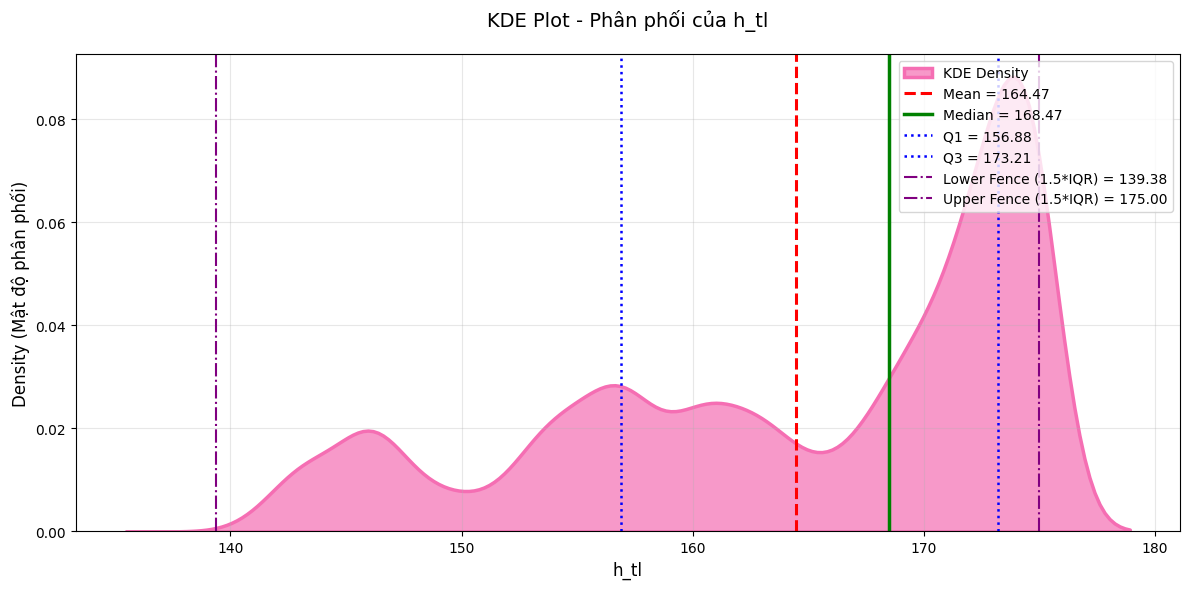

============== H_DBT ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 175.0000
• Độ lệch chuẩn (std) : 0.0000
• Giá trị nhỏ nhất    : 175.0000
• Phân vị 25% (Q1)    : 175.0000
• Median (50%)        : 175.0000
• Phân vị 75% (Q3)    : 175.0000
• Giá trị lớn nhất    : 175.0000
• Skewness            : 0.0000


C:\Users\ACER\AppData\Local\Temp\ipykernel_15800\3665294597.py:31: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=col, fill=True, color="#F56EB3",


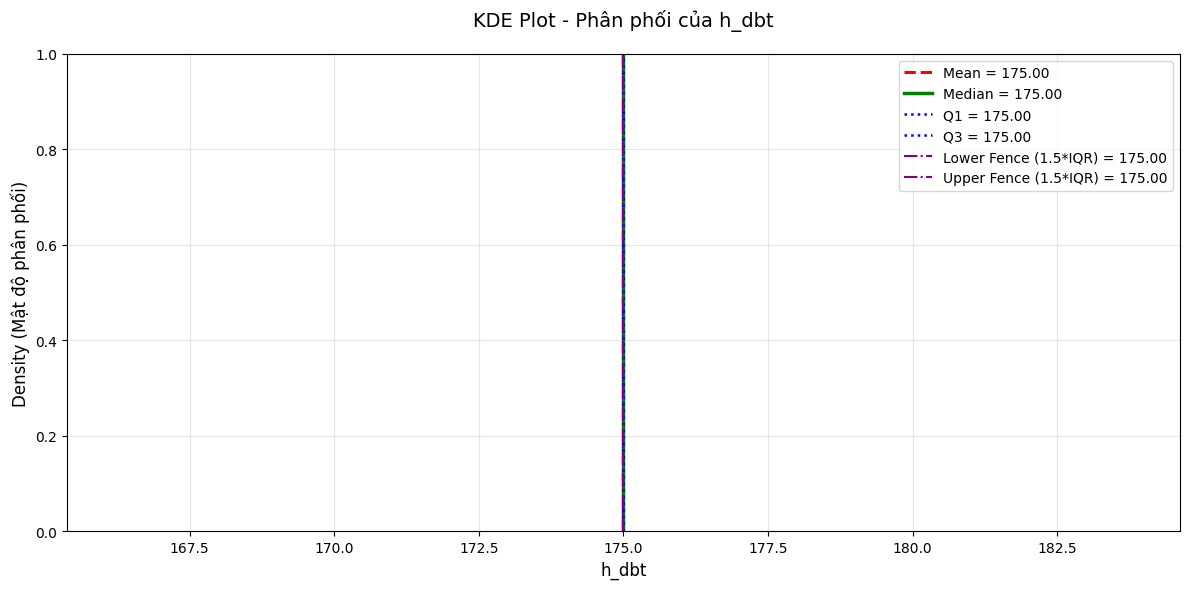

============== H_C ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 140.0000
• Độ lệch chuẩn (std) : 0.0000
• Giá trị nhỏ nhất    : 140.0000
• Phân vị 25% (Q1)    : 140.0000
• Median (50%)        : 140.0000
• Phân vị 75% (Q3)    : 140.0000
• Giá trị lớn nhất    : 140.0000
• Skewness            : 0.0000


C:\Users\ACER\AppData\Local\Temp\ipykernel_15800\3665294597.py:31: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=col, fill=True, color="#F56EB3",


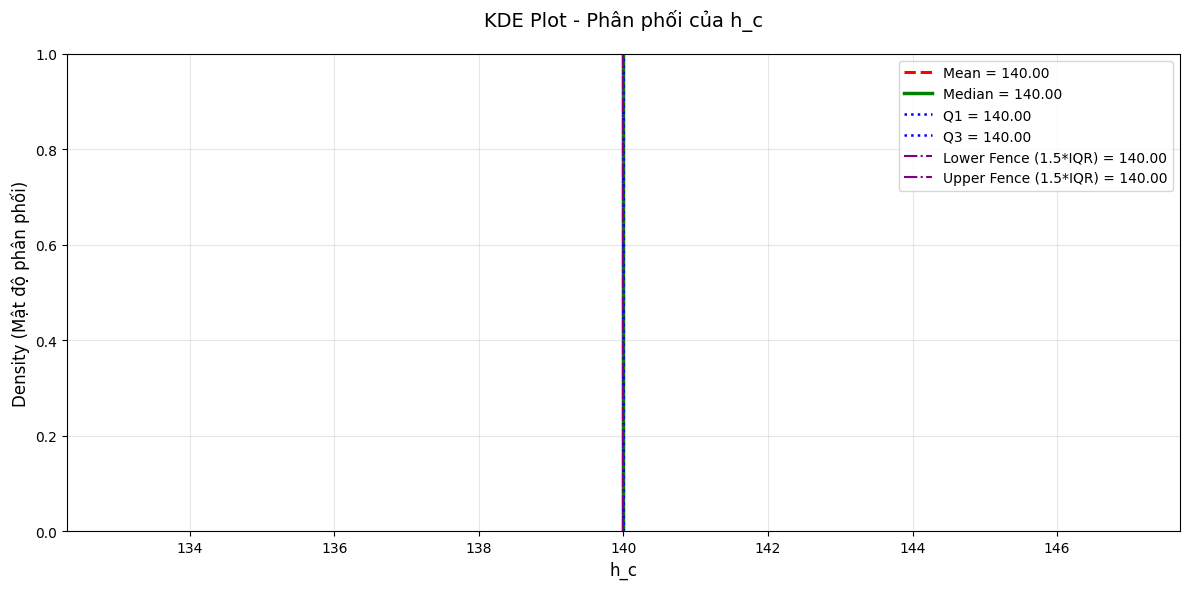

============== Q_VE ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 121.5327
• Độ lệch chuẩn (std) : 180.3986
• Giá trị nhỏ nhất    : 2.9400
• Phân vị 25% (Q1)    : 45.1000
• Median (50%)        : 69.1100
• Phân vị 75% (Q3)    : 133.6750
• Giá trị lớn nhất    : 4086.8500
• Skewness            : 6.3591


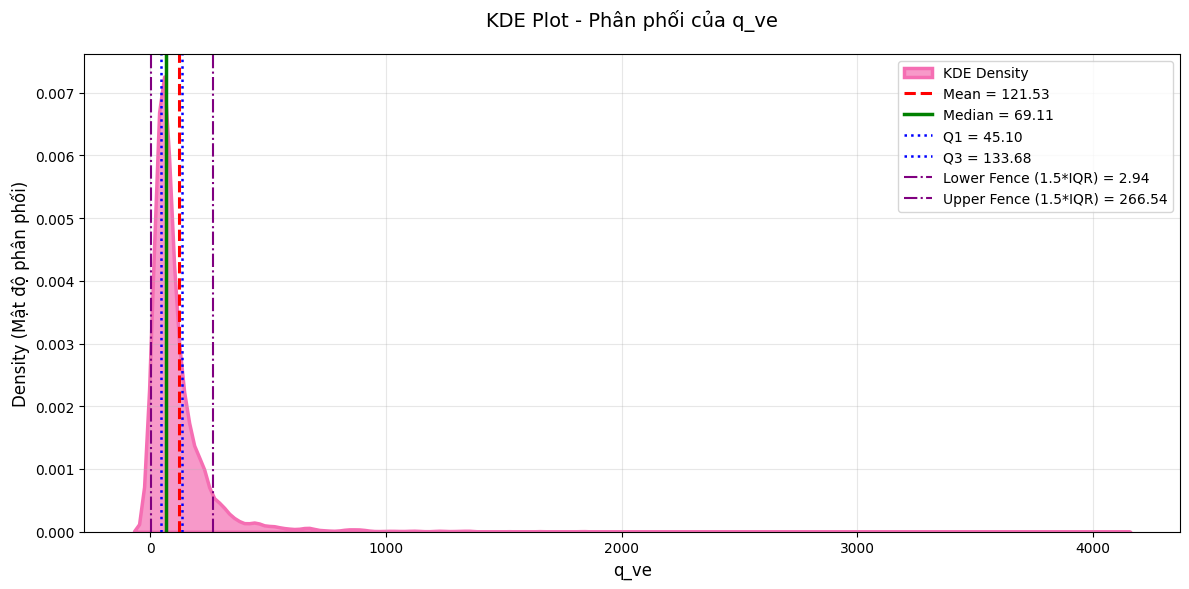

============== SIGMA_QX ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 121.7537
• Độ lệch chuẩn (std) : 134.1284
• Giá trị nhỏ nhất    : 5.7000
• Phân vị 25% (Q1)    : 5.7600
• Median (50%)        : 105.7000
• Phân vị 75% (Q3)    : 203.7700
• Giá trị lớn nhất    : 1768.6500
• Skewness            : 3.4670


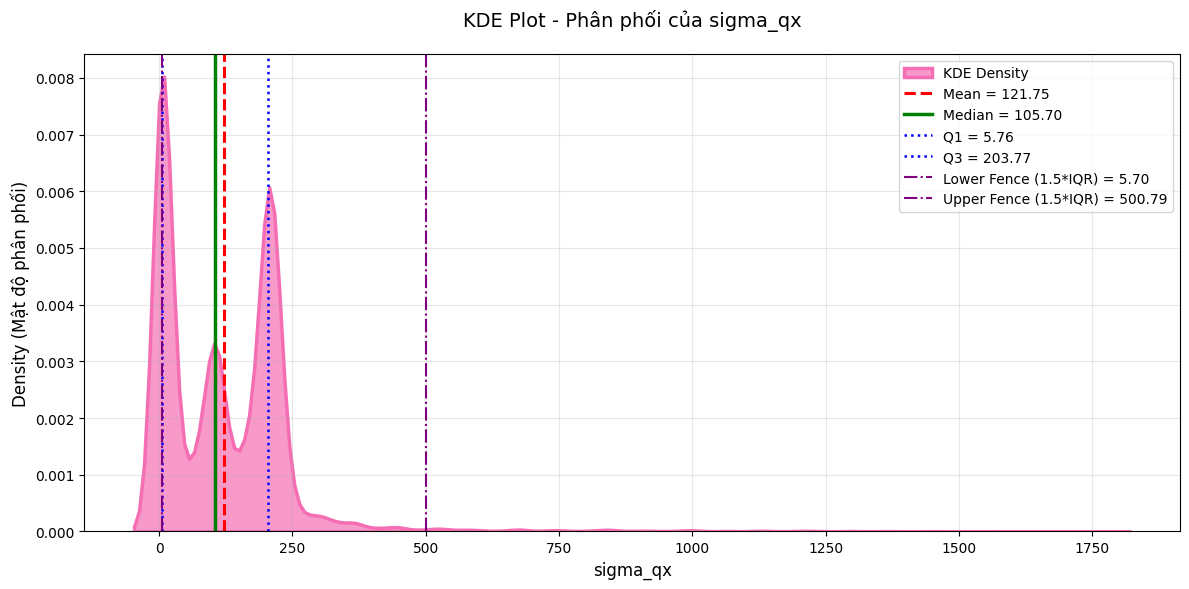

============== Q_XT ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 20.5484
• Độ lệch chuẩn (std) : 86.9497
• Giá trị nhỏ nhất    : 5.7000
• Phân vị 25% (Q1)    : 5.7000
• Median (50%)        : 5.7000
• Phân vị 75% (Q3)    : 5.7700
• Giá trị lớn nhất    : 1568.6500
• Skewness            : 9.2558


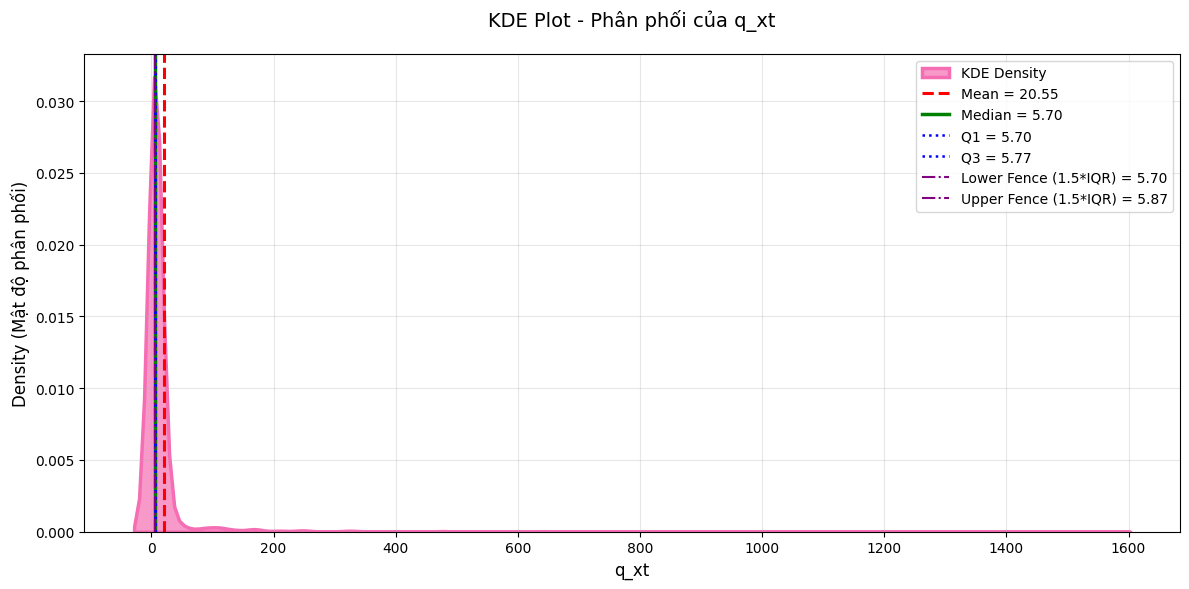

============== Q_XM ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 101.2052
• Độ lệch chuẩn (std) : 86.6637
• Giá trị nhỏ nhất    : 0.0000
• Phân vị 25% (Q1)    : 0.0000
• Median (50%)        : 100.0000
• Phân vị 75% (Q3)    : 198.0000
• Giá trị lớn nhất    : 232.0000
• Skewness            : -0.0091


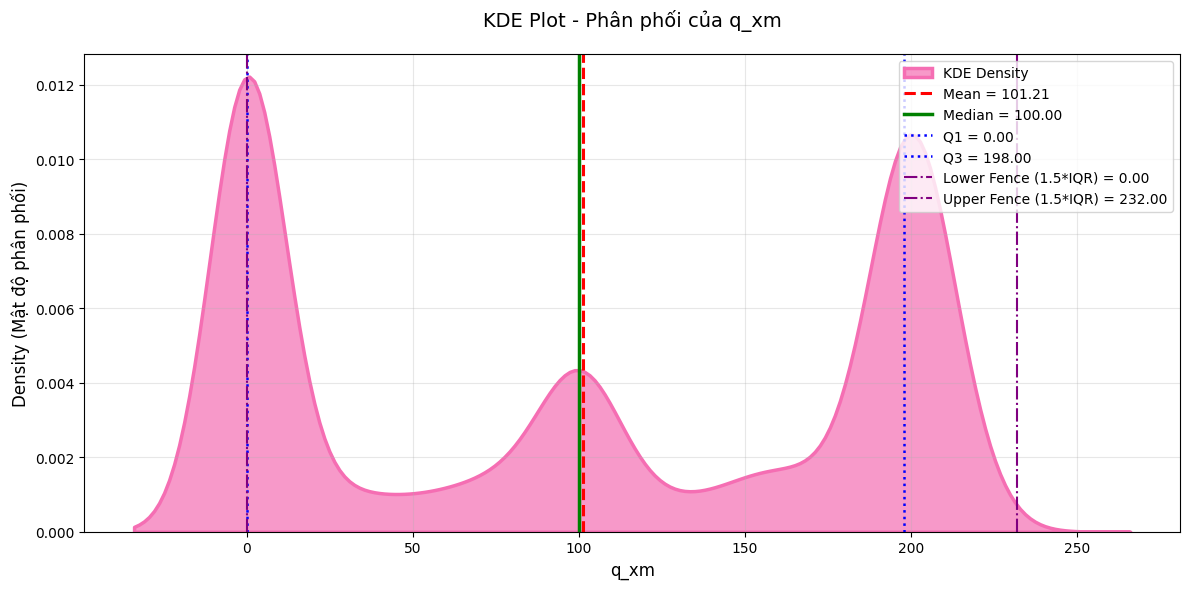

============== N_CXS ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 0.0044
• Độ lệch chuẩn (std) : 0.6793
• Giá trị nhỏ nhất    : 0.0000
• Phân vị 25% (Q1)    : 0.0000
• Median (50%)        : 0.0000
• Phân vị 75% (Q3)    : 0.0000
• Giá trị lớn nhất    : 110.0000
• Skewness            : 161.4870


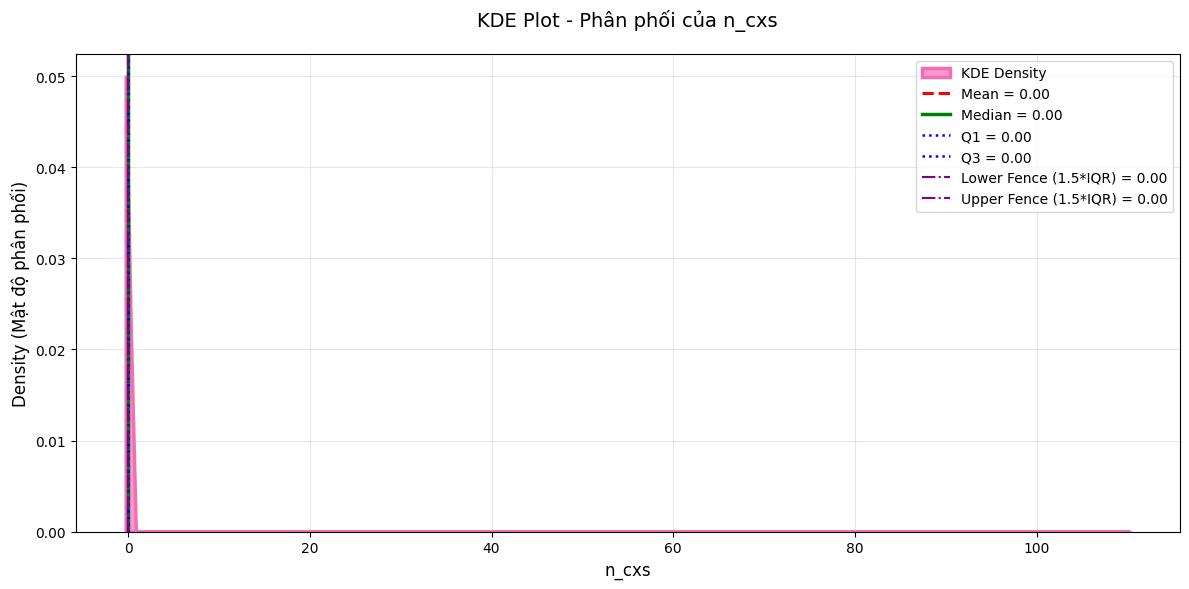

============== N_CXM ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 0.1727
• Độ lệch chuẩn (std) : 0.6287
• Giá trị nhỏ nhất    : 0.0000
• Phân vị 25% (Q1)    : 0.0000
• Median (50%)        : 0.0000
• Phân vị 75% (Q3)    : 0.0000
• Giá trị lớn nhất    : 6.0000
• Skewness            : 5.8171


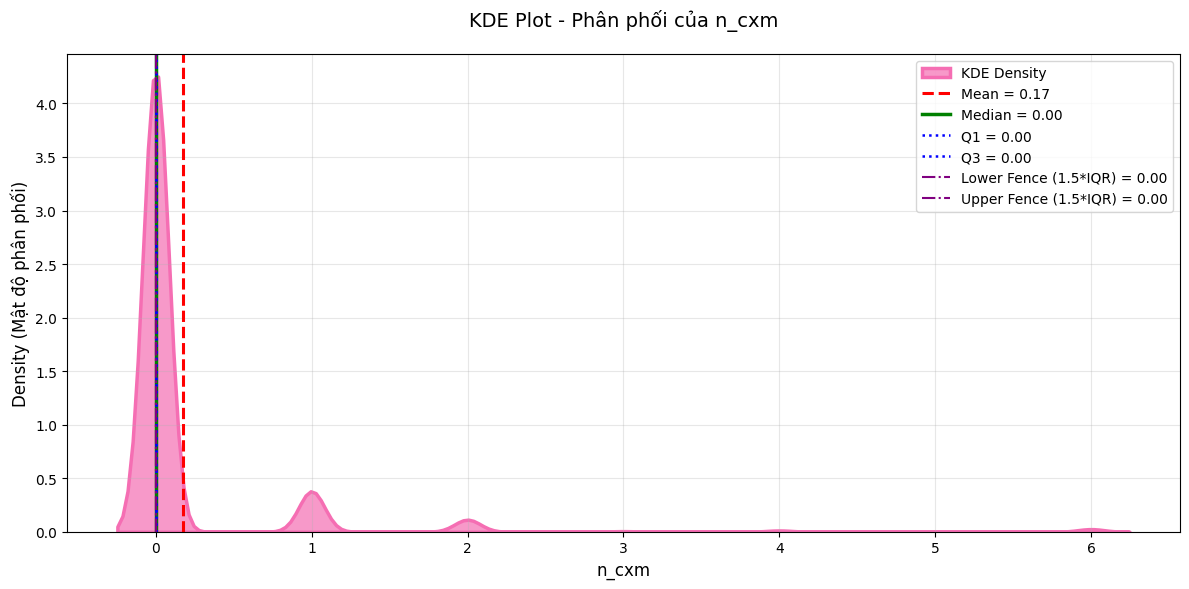

============== TEMPERATURE ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 21.4998
• Độ lệch chuẩn (std) : 3.7133
• Giá trị nhỏ nhất    : 9.9300
• Phân vị 25% (Q1)    : 19.1200
• Median (50%)        : 21.3800
• Phân vị 75% (Q3)    : 23.8000
• Giá trị lớn nhất    : 34.8500
• Skewness            : 0.1583


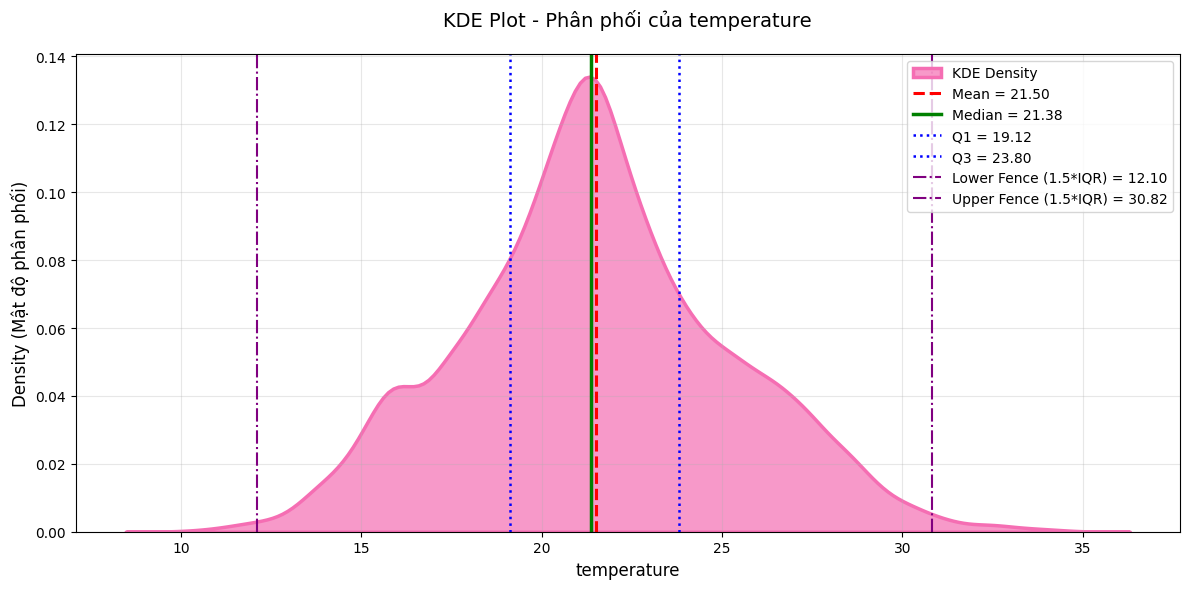

============== HUMIDITY ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 86.1734
• Độ lệch chuẩn (std) : 11.2635
• Giá trị nhỏ nhất    : 31.7500
• Phân vị 25% (Q1)    : 79.7500
• Median (50%)        : 89.5000
• Phân vị 75% (Q3)    : 95.0000
• Giá trị lớn nhất    : 100.0000
• Skewness            : -1.1391


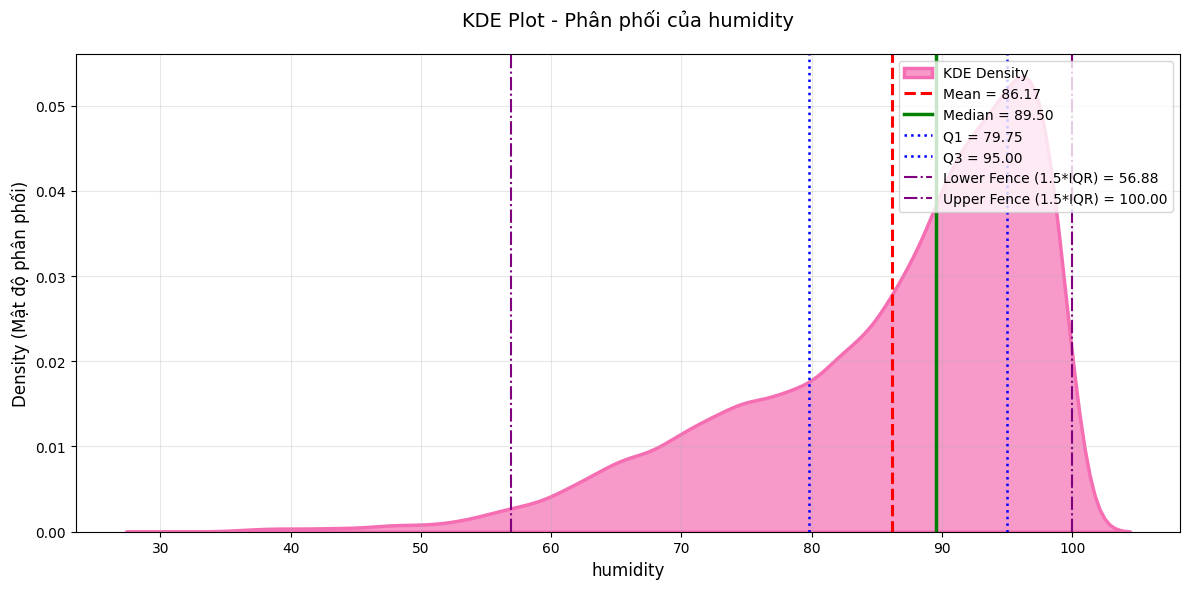

============== PRECIPITATIONS ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 0.3866
• Độ lệch chuẩn (std) : 1.0182
• Giá trị nhỏ nhất    : 0.0000
• Phân vị 25% (Q1)    : 0.0000
• Median (50%)        : 0.0500
• Phân vị 75% (Q3)    : 0.3000
• Giá trị lớn nhất    : 20.4000
• Skewness            : 6.3599


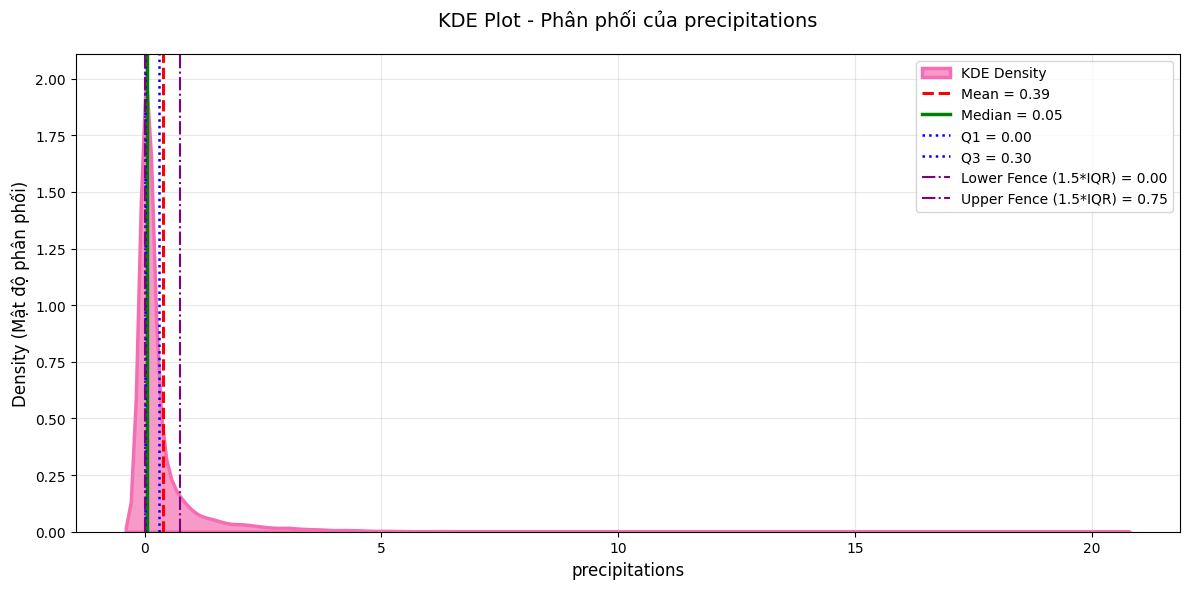

============== WIND_SPEEDS ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 4.8427
• Độ lệch chuẩn (std) : 2.2651
• Giá trị nhỏ nhất    : 0.4200
• Phân vị 25% (Q1)    : 3.1700
• Median (50%)        : 4.3000
• Phân vị 75% (Q3)    : 6.0000
• Giá trị lớn nhất    : 22.0800
• Skewness            : 1.2850


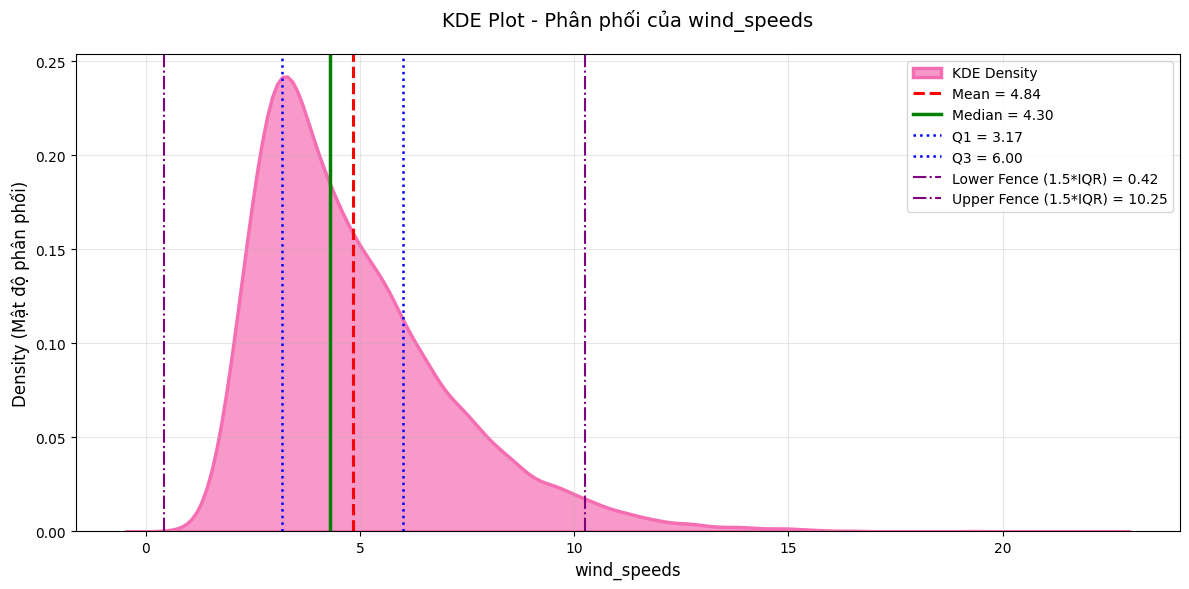

============== WIND_DIRECTION ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 156.5986
• Độ lệch chuẩn (std) : 68.8235
• Giá trị nhỏ nhất    : 9.5000
• Phân vị 25% (Q1)    : 102.7500
• Median (50%)        : 172.0000
• Phân vị 75% (Q3)    : 213.5000
• Giá trị lớn nhất    : 357.7500
• Skewness            : -0.2785


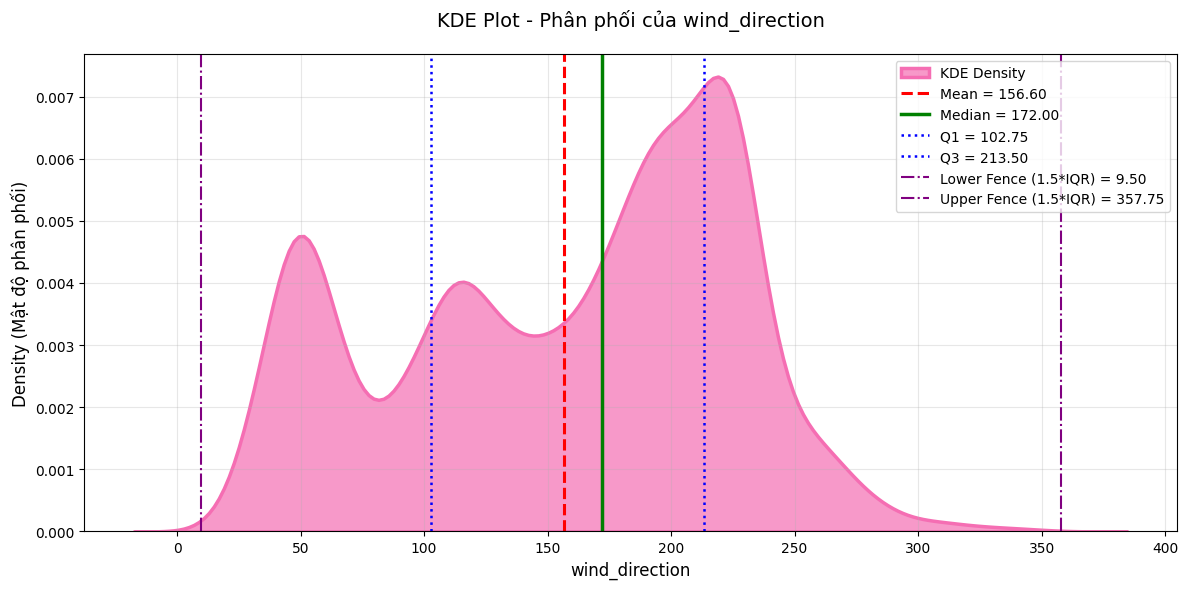

============== CLOUD_COVER_MID ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 24.0771
• Độ lệch chuẩn (std) : 28.1574
• Giá trị nhỏ nhất    : 0.0000
• Phân vị 25% (Q1)    : 2.0000
• Median (50%)        : 12.5000
• Phân vị 75% (Q3)    : 36.0000
• Giá trị lớn nhất    : 100.0000
• Skewness            : 1.2656


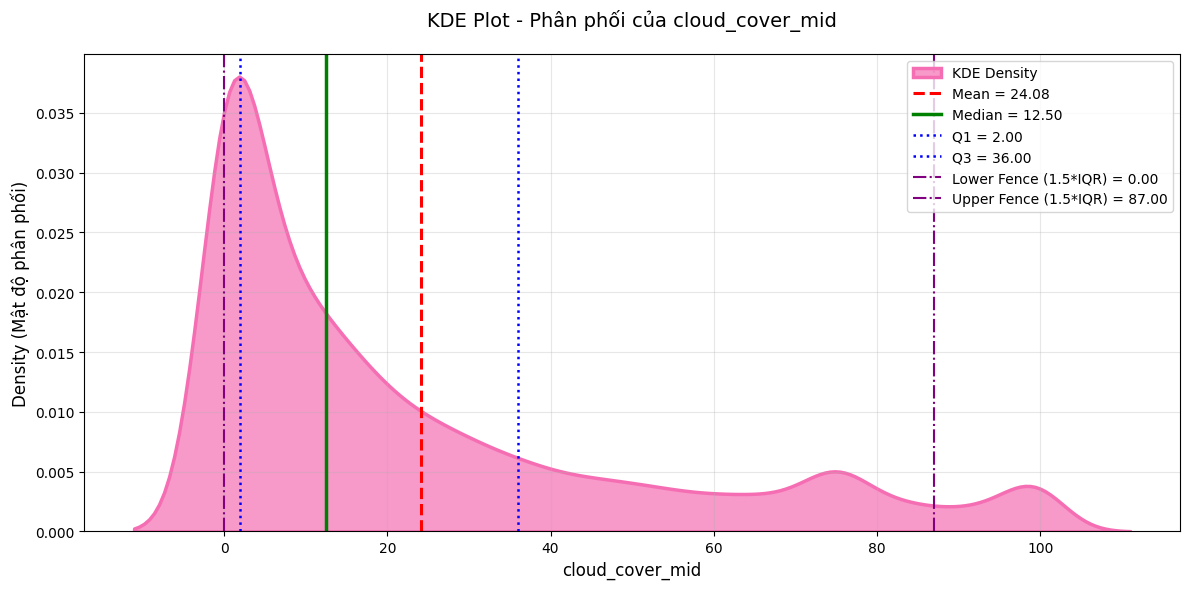

============== PRESSURE ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 1012.5150
• Độ lệch chuẩn (std) : 4.6447
• Giá trị nhỏ nhất    : 990.7500
• Phân vị 25% (Q1)    : 1009.0500
• Median (50%)        : 1012.2500
• Phân vị 75% (Q3)    : 1015.8500
• Giá trị lớn nhất    : 1027.2800
• Skewness            : 0.1543


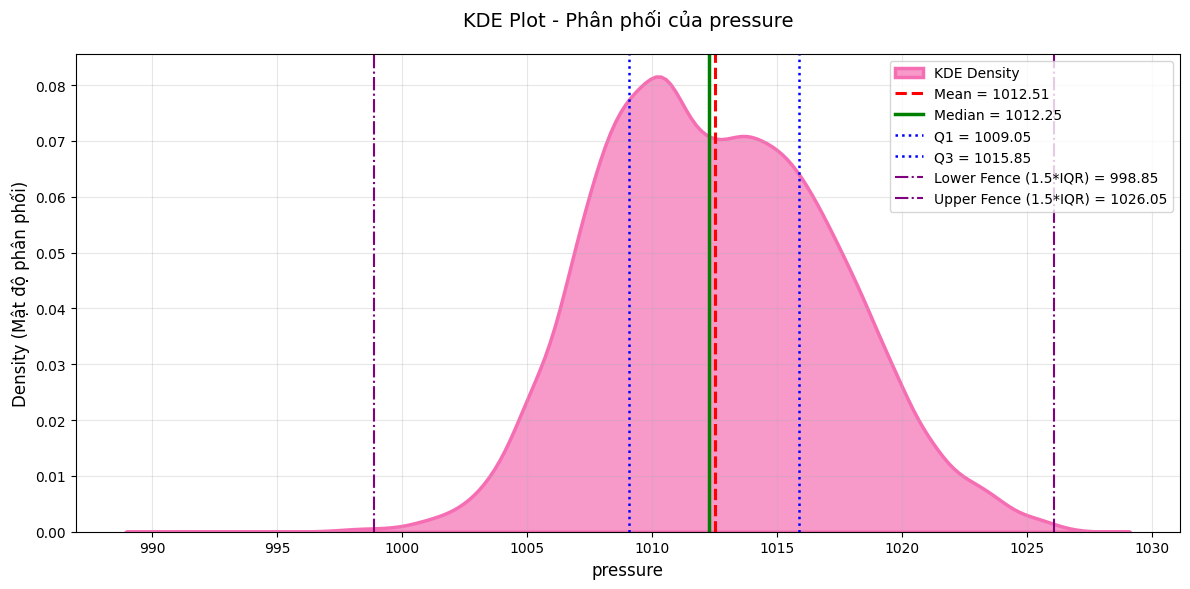

============== SOIL_MOISTURE_0_7CM ==============
Thông tin thống kê:
• Số quan sát (count) : 26,303
• Trung bình (mean)   : 0.4611
• Độ lệch chuẩn (std) : 0.0492
• Giá trị nhỏ nhất    : 0.2700
• Phân vị 25% (Q1)    : 0.4400
• Median (50%)        : 0.4800
• Phân vị 75% (Q3)    : 0.5000
• Giá trị lớn nhất    : 0.5200
• Skewness            : -1.5708


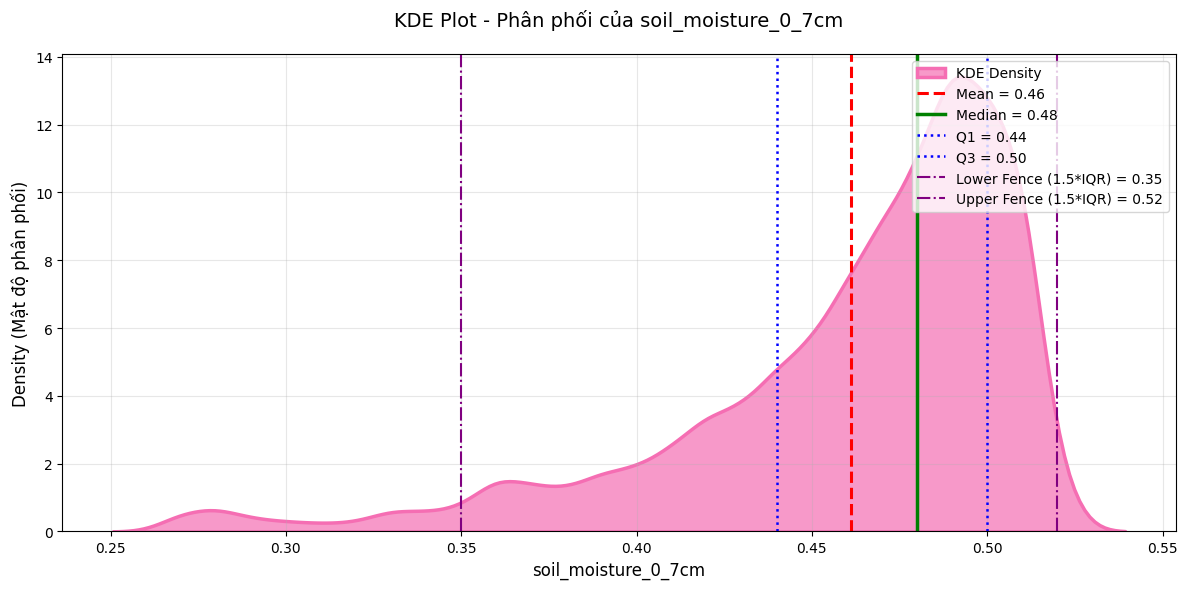

In [11]:
for col in FEAT_COLS:
    if col in ["time", "ten_ho"]:
        continue
    analyze_univariate(train_df, col)

- `H_tl`: Phân phối phức tạp với nhiều đỉnh nhưng biểu đồ không bị dẹt quá cho thấy đây là xu hướng biến động thực tế, không phải outlier.
- `H_dbt`: là giá trị cố định, không đóng góp trong việc dự đoán.
- `H_c`: là giá trị cố định, không đóng góp trong việc dự đoán.
- `Q_ve`: lệch phải nặng, đa số lượng nước về hồ ở mức thấp, các giá trị cao đột biến có thể do lỗi đo đạc hoặc do mưa lũ.
- `Sigma_Qx` lệch phải nặng, có 3 đỉnh rõ ràng khá giống Q_xm. Khả năng cao xu hướng biến đổi sẽ phụ thuộc Q_xm nhưng giá trị chịu ảnh hưởng nhiều hơn bởi Q_xt.
- `Q_xt` lệch phải nặng, đóng góp nhiều vào Sigma_Qx khi giá trị lớn tức là mưa lũ xuất hiện.
- `Q_xm`: có khoảng giá trị rõ rệt với 3 đỉnh, phụ thuộc vào lịch xả và yếu tố con người.
- `N_cxs`: các cửa xả sâu thường không mở, đột biến với 110 cửa khi mưa lũ.
- `N_cxm`: thường ít được mở, thỉnh thoảng sẽ mở 1, 2 cửa hoặc 6 cửa nếu lượng nước quá nhiều.

- `Temperature` có phân phối gần phân phối chuẩn nhưng hơi nhọn, ít outlier chủ yếu trong khoảng 19-23 độ C.
- `Humidity` lệch trái khá nặng, cho thấy phần lớn quan sát có độ ẩm cao. 
- `Precipitations`: lệch phải nặng, các giá trị cao đột biến có thể do mưa nhiều hoặc lũ quét. Khoảng giá trị nhìn chung ở mức thấp.
- `Wind_speeds`: lệch phải, cho thấy tốc độ gió thường không cao, thi thoảng gió mạnh dẫn tới phần đuôi bên phải.
- `Wind_direction`: hướng gió khá phức tạp, cho thấy gió thổi từ nhiều phía nhưng chủ yếu là gió Tây Nam.
- `Cloud_cover_mid`: độ che phủ của mây cũng phức tạp, lệch phải nhưng không hoàn toàn là outlier do độ rộng của đuôi bên phải cũng không phải quá thấp.
- `Pressure`: khá gần phân phối chuẩn nhưng bị lệch nhẹ về bên phải, phần đuôi bên trái mảnh, cho thấy 1 số giá trị thấp hơn hẳn xuất hiện khá ít.
- `Soil_moisture_0_7cm`: lệch trái nhiều, cho thấy độ ẩm đất thường ở mức cao, tuy nhiên phần dưới lower fence vẫn có khá nhiều quan sát, khó để đánh giá là outlier.

## Correlation

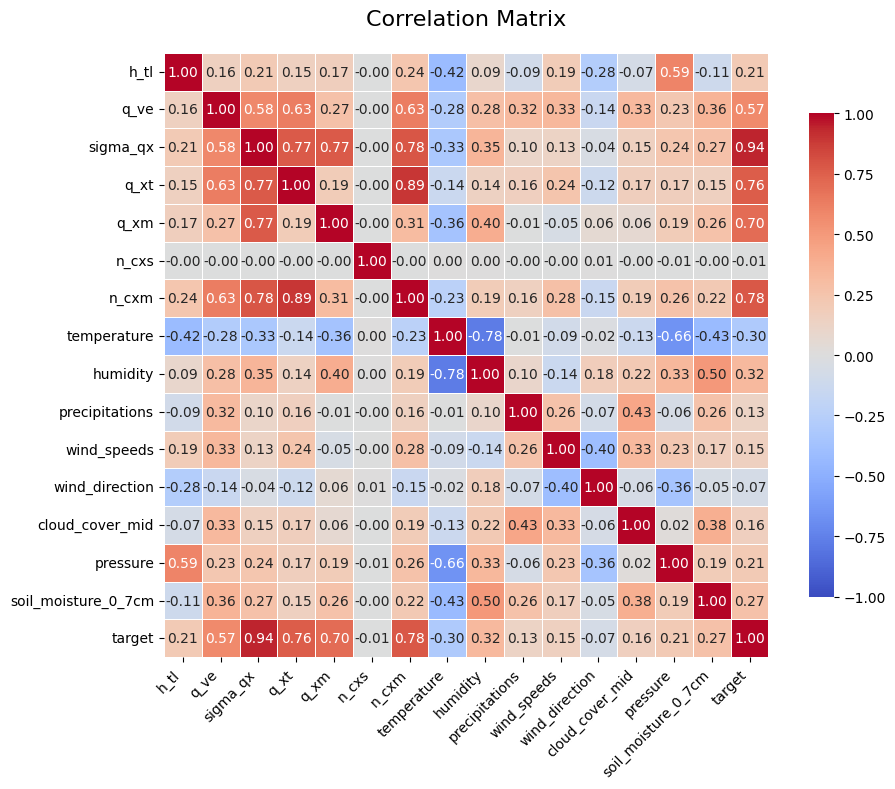

In [12]:
COLS = [
    'h_tl', 'q_ve', 'sigma_qx', 'q_xt', 'q_xm', 'n_cxs', 'n_cxm',
    'temperature', 'humidity', 'precipitations', 'wind_speeds',
    'wind_direction', 'cloud_cover_mid', 'pressure', 'soil_moisture_0_7cm', 'target',
]

plot_correlation_matrix(
    train_df, columns=COLS,
    title="Correlation Matrix",
    figsize=(10, 8),
)

- Tương quan giữa các biến thời tiết với biến hồ thủy điện thường ở mức vừa phải, ngoại trừ cặp `pressure` vs `h_tl` khá cao với 0.59, tuy nhiên đây có thể không phải quan hệ nhân quả vì không có tài liệu nào cho thấy khi áp suất không khí cao thì mực nước tại hồ thủy điện cũng cao và ngược lại.
- `sigma_qx` có tương quan dương khá cao với `Q_xt` và `Q_xm`, `n_csm` vì đúng theo lý thuyết `sigma_qx` = `Q_xm` + `Q_xt`. Và `n_csm` tương quan cũng rất cao với `Q_xt` cho thấy để xả qua đập tràn thường dùng các cửa xả mặt (điều tiết lũ thông thường) thay vì các cửa xả sâu (cắt lũ nhanh).
- `temperature` và `humidity` có tương quan nghịch mạnh, cho thấy càng nóng thì không khí càng khô. Giữa `temperature` với `pressure` cũng có tương quan nghịch khá mạnh, tức là nhiệt độ cao có thể đi kèm áp suất không khí thấp.
- Đặc biệt, `target` có tương quan tuyến tính rất lớn tới `sigma_qx`, `q_xt`, `q_xm`, `q_ve`, `n_cxm`. Cho thấy tổng lượng xả chịu ảnh hưởng nhiều hơn bởi lưu lượng nước vào/ra vào thời điểm trước đó.

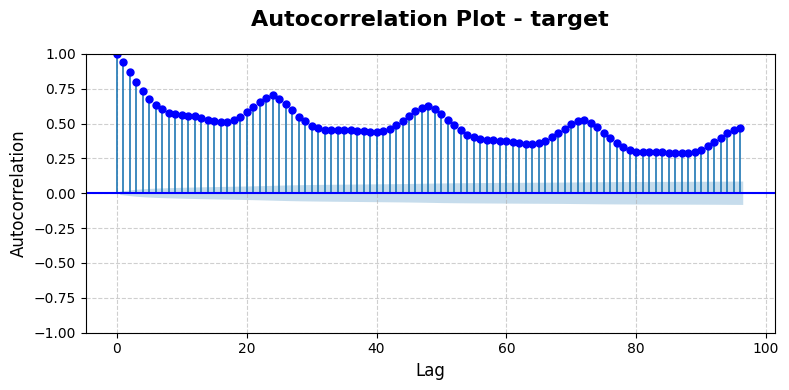

In [13]:
# Autocorrelation của target
plot_autocorrelation(train_df, column='target', lags=96, figsize=(8, 4))

`Target` có tính tự tương quan khá mạnh, thể hiện rằng giá trị hiện tại phụ thuộc khá nhiều vào các thời điểm trước đó. Biểu đồ cũng cho thấy target có tính trend kết hợp với seasonal với chu kỳ 24 nên việc bổ sung lag tại 24 giờ trước cũng khá quan trọng.  
-> để cải thiện hiệu quả dự đoán, có thể dùng thêm các lag_feature với khung giờ gần như lag_1, lag2_, lag3 để nắm bắt xu hướng, lag_24 để nắm bắt chu kỳ.  
-> nếu dùng các mô hình feature-base (không cảm nhận được yếu tố chuỗi thời gian): thêm các đặc trưng thời gian như ngày/tháng/năm/giờ.

## Time series

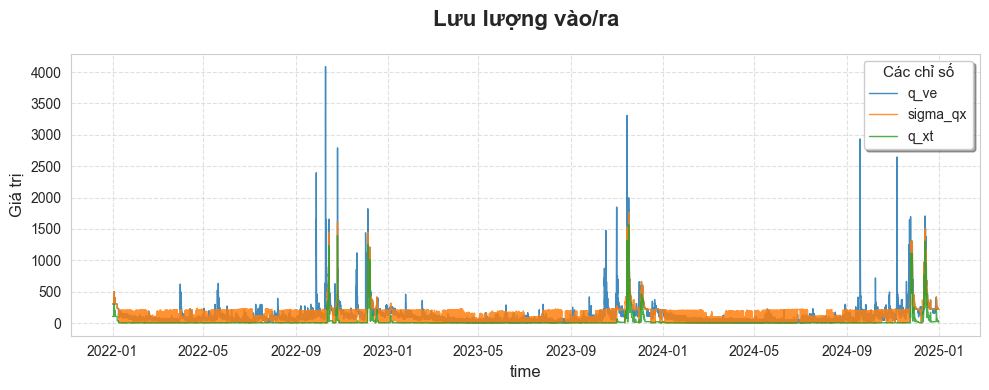

In [14]:
plot_time_series(
    train_df,
    columns=['q_ve', 'sigma_qx', 'q_xt'],
    time_column='time',
    title='Lưu lượng vào/ra',
    figsize=(10, 4),
)

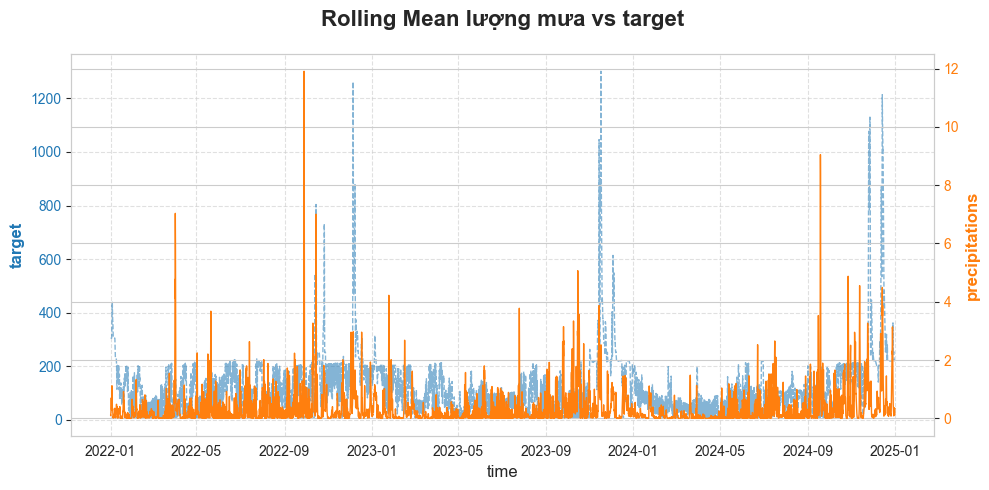

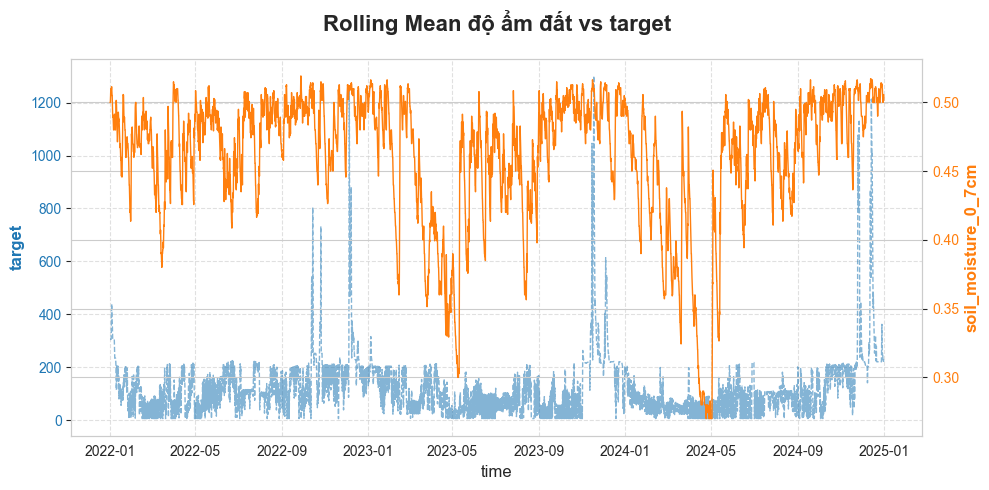

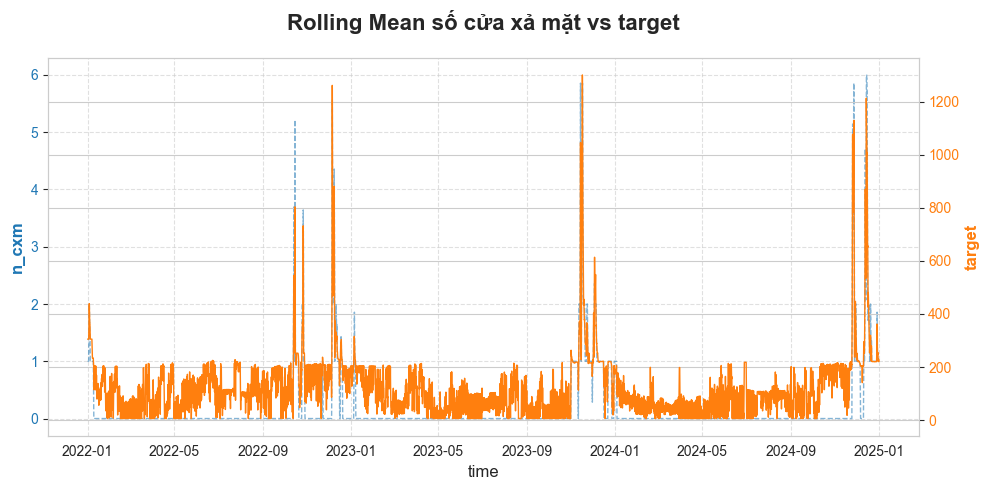

In [15]:
plot_rolling_2_axis(train_df, columns=['target', 'precipitations'],
                    time_column='time', rolling=14,
                    title='Rolling Mean lượng mưa vs target', figsize=(10, 5))

plot_rolling_2_axis(train_df, columns=['target', 'soil_moisture_0_7cm'],
                    time_column='time', rolling=14,
                    title='Rolling Mean độ ẩm đất vs target', figsize=(10, 5))

plot_rolling_2_axis(train_df, columns=['n_cxm', 'target'],
                    time_column='time', rolling=14,
                    title='Rolling Mean số cửa xả mặt vs target', figsize=(10, 5))

Ta thấy target (sigma_qx) thường có pattern biến động theo chu kỳ năm, trong đó sẽ có những thời điểm ở mức ổn định là từ cuối tháng 1 - giữa tháng 10, có những thời điểm tăng độ biến là nửa sau tháng 10 - nửa đầu tháng 1, hoàn toàn tương ứng với mùa mưa bão ở nước ta,
- Trong giai đoạn ổn định, sigma_qx thường biến đổi và chịu ảnh hưởng nhiều hơn bởi q_xm do không cần xả nước tránh lũ.
- Trong giai đoạn bất ổn định, sigma_qx chịu ảnh hưởng nhiều hơn bởi q_xt do cần điều tiết lũ.
- Đồng thời, trong quá trình xả tràn, cần mở các cửa mặt nên vào giai đoạn bất ổn định, số cửa xả mặt được mở tăng lên và tương ứng sigma_qx cũng tăng.
- Lượng mưa và độ ẩm đất về mặt lý thuyết sẽ ảnh hưởng tới q_ve và gián tiếp ảnh hưởng tới target, khó có thể nhìn thấy qua biểu đồ.

# Bước 3: Preprocessing & Feature Engineering

**<h2>Preprocessing</h2>**
**Drop các cột không cần thiết**
- Đối với ten_ho: do hiện tại chỉ thử nghiệm mỗi hồ 1 mô hình (không gộp chung) nên không cần cột ten_ho -> drop. Nếu muốn dùng chung thì dùng one hot encoding do đây là biến nominal.
- Đối với h_c và h_dbt: là hằng số, không có tác dụng với phương sai của dữ liệu -> drop.
- Bỏ "time" với các mô hình feature-based sau khi đã tạo thêm các cột thời gian khác.

**Outlier**
- Bộ dữ liệu có 1 số giá trị xuất hiện ít -> Đánh giá là outlier
- Tuy nhiên các outlier này thực tế không phải noise mà là thông tin chính xác -> không lọc bỏ.

**<h2>Feature Engineering</h2>**
**Giảm lệch & Biến đổi về phân phối chuẩn**
- Chỉ áp dụng với các thuật toán cần đến scale dữ liệu như Linear Regression, Ridge, Lasso, Neural Network. Các tree-based method thì không cần.
- Tree-based: việc giảm lệch và chuẩn hóa là không cần thiết, tuy nhiên nếu dữ liệu bị lệch quá lớn, vẫn giảm lệch để đảm bảo an toàn. 
    - Áp dụng YeoJohnsonTransformer với skewness threshold là +-1.8: `q_ve`(6.3591), `sigma_qx`(3.4670), `q_xt`(9.2558), `n_cxs`(161.4870), `n_cxm`(5.8171), `precipitations`(6.3599)
    - Không chuẩn hóa.
- Distance-based, neural network: thông tin về khoảng cách là quan trọng nên cần chuẩn hóa dữ liệu để tránh lệch scale về cột nào đó.
    - Áp dụng trên các cột bị lệch với skewness threshold là +-1, bao gồm các cột:
        - Lệch phải nặng: `q_ve`(6.3591), `sigma_qx`(3.4670), `q_xt`(9.2558), `n_cxs`(161.4870),
                        `n_cxm`(5.8171), `precipitations`(6.3599), `wind_speeds`(1.2850), 
                        `cloud_cover_mid` (1.2656)
        - Lệch trái nặng: `humidity` (-1.1391), `soil_moisture_0_7_cm` (-1.5708)
    - Sử dụng thuật toán YeoJohnsonTransformer, với ưu điểm tự adapt lamda cho phù hợp với mọi kiểu lệch dữ liệu (trái, phải).
    - Dùng thêm Standard Scaler để scale dữ liệu toàn bộ bảng.

**Thêm đặc trưng mới**
- Thêm các lag feature của `sigma_qx`. Vì target là `sigma_qx` tại t+1, nên cần tạo lag tại thời điểm t-1, t-2, t-3 -> shift `sigma_qx` tại 3 dòng phía trên xuống để tạo lag -> mất 3 dòng đầu của train và test là null -> drop.
- Thêm feature thời gian vì các mô hình feature-based không đọc được cột "time": thêm `hour`, `month`, `year` và áp dụng sin_cos encoding cho hour và month để giữ tính chu kỳ.
- Thêm feature `is_flood` để đánh giá mùa bão. is_flood = 1 nếu vào các tháng được cho là bão (10-1) và q_ve đạt ngưỡng (750).

**<h2>Thứ tự chạy</h2>**
- Bước 1: Drop cột không cần thiết
- Bước 2: Flood flag
- Bước 3: Transform (Yeo-Johnson + StandardScaler) hoặc (Yeo-Johnson)
- Bước 4: Lag features
- Bước 5: Time features
- Bước 6: Drop cột time

### Chạy cho trường hợp có dùng standard scaler -> các mô hình khoảng cách, neural network

In [16]:
train_processed, info = run_pipeline(
        df=train_df,
        cols_to_drop=COLS_TO_DROP,
        skew_cols=SKEW_COLS,
        scale_cols=SCALE_COLS,
        use_standardize=True,
        fit_transformers=True,   # fit trên train
        verbose=True
    )


───────────────────────────────────────────────────────
  Pipeline — TRAIN  (input shape: (26303, 20))
───────────────────────────────────────────────────────

[1] Drop unnecessary columns
Đã drop 3 cột: ['h_dbt', 'h_c', 'ten_ho']

[2] Flood flag
Đã tạo cột 'is_flood' với flood_months=[10, 11, 12, 1] và q_ve_threshold=750

[3] Transform (skewness + scale)
Đã áp dụng Yeo-Johnson trên 10 cột:
   • q_ve                      → λ = 0.0627
   • sigma_qx                  → λ = 0.2247
   • q_xt                      → λ = -3.9081
   • n_cxs                     → λ = -3952.1052
   • n_cxm                     → λ = -10.3047
   • precipitations            → λ = -3.4407
   • wind_speeds               → λ = -0.3309
   • cloud_cover_mid           → λ = 0.1155
   • humidity                  → λ = 4.6131
   • soil_moisture_0_7cm       → λ = 19.5524

Đã áp dụng StandardScaler trên 15 cột

Transform hoàn tất!
   - Sử dụng Yeo-Johnson : 10 cột
   - Sử dụng StandardScaler : Có

[4] Lag features — cột 'sig

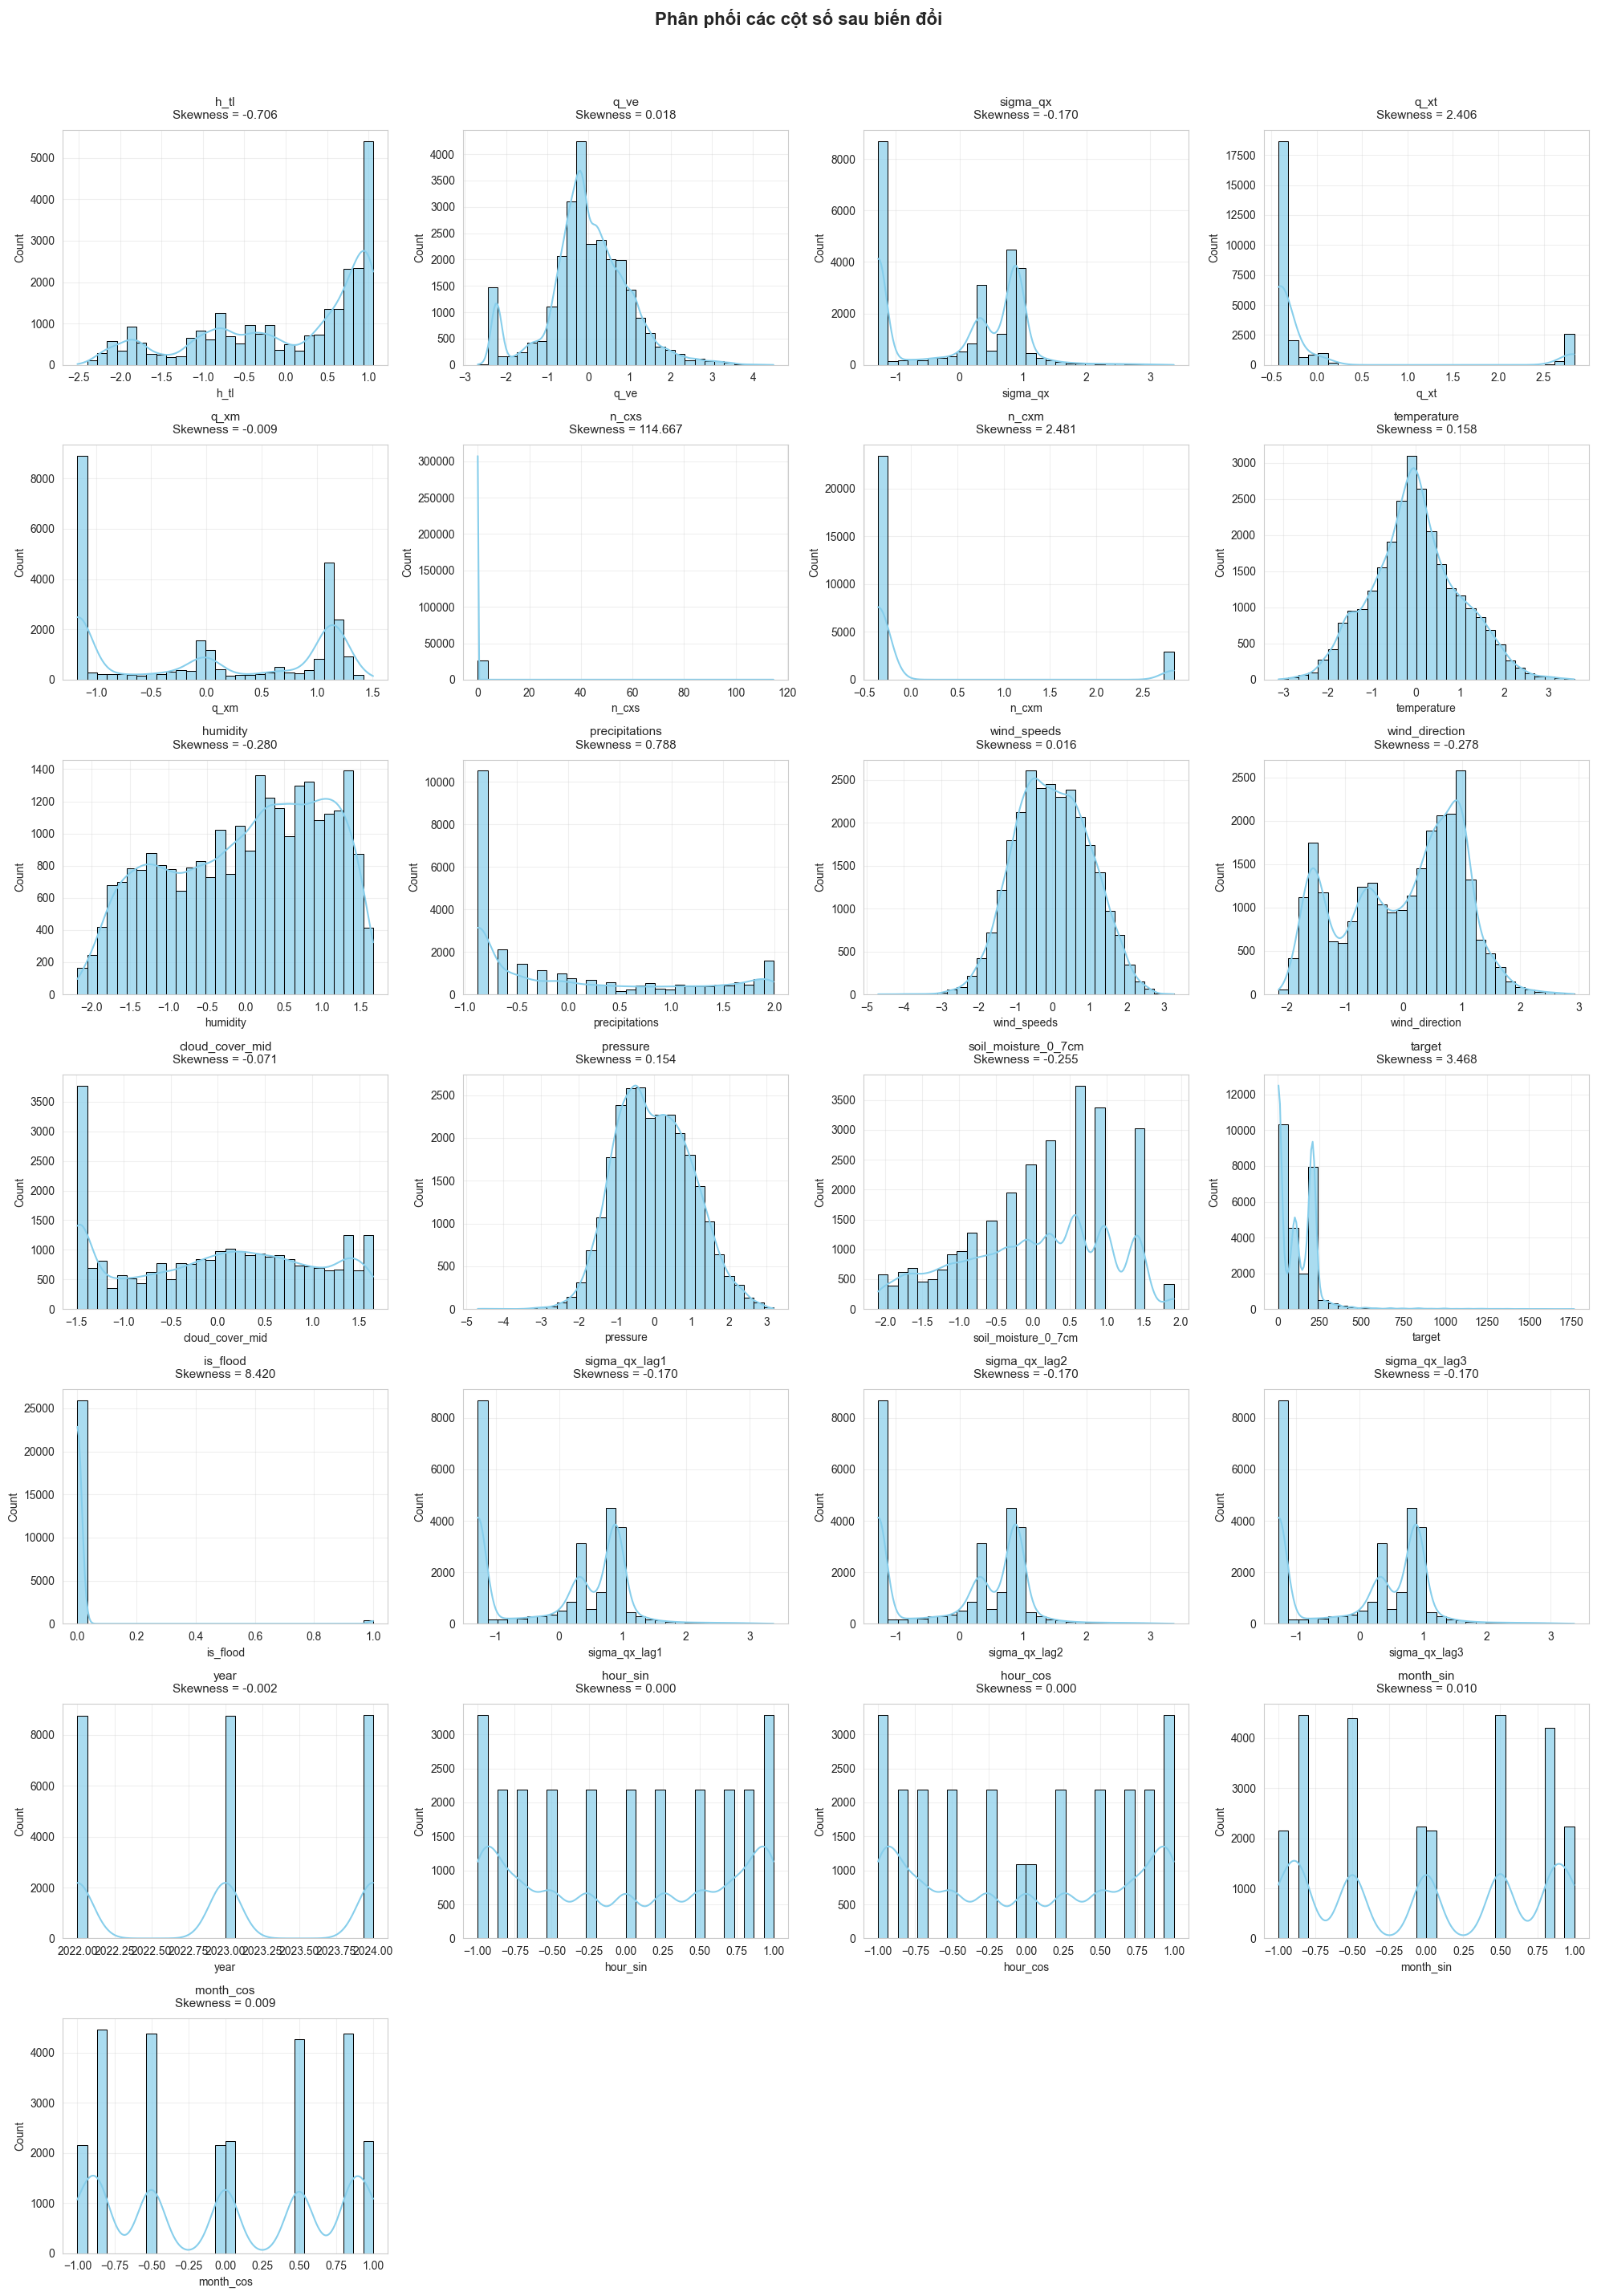

In [17]:
plot_distributions(train_processed, title="Phân phối các cột số sau biến đổi")

In [18]:
# Apply pipeline lên test
test_processed, _ = run_pipeline(
        df=test_df,
        cols_to_drop=COLS_TO_DROP,
        skew_cols=SKEW_COLS,
        scale_cols=SCALE_COLS,
        use_standardize=True,
        fit_transformers=False,  # chỉ transform, không fit lại
        transform_info=info,
        verbose=True,
    )


───────────────────────────────────────────────────────
  Pipeline — TEST  (input shape: (8759, 20))
───────────────────────────────────────────────────────

[1] Drop unnecessary columns
Đã drop 3 cột: ['h_dbt', 'h_c', 'ten_ho']

[2] Flood flag
Đã tạo cột 'is_flood' với flood_months=[10, 11, 12, 1] và q_ve_threshold=750

[3] Transform (skewness + scale)
   Áp dụng Yeo-Johnson (đã fit) trên 10 cột
   Áp dụng StandardScaler (đã fit) trên 15 cột

[4] Lag features — cột 'sigma_qx', lags=[1, 2, 3]
Đã thêm 3 lag features cho cột 'sigma_qx': ['sigma_qx_lag1', 'sigma_qx_lag2', 'sigma_qx_lag3']

[5] Time features
Đã thêm time features với Cyclic Encoding (sin/cos)

  Pipeline hoàn tất — output shape: (8756, 25)


### Chạy cho trường hợp không dùng standard scaler -> tree-based

In [19]:
SKEW_COLS = ['q_ve', 'sigma_qx', 'q_xt', 'n_cxs', 'n_cxm', 'precipitations',]

In [20]:
train_processed_tree, info_tree = run_pipeline(
        df=train_df,
        cols_to_drop=COLS_TO_DROP,
        skew_cols=SKEW_COLS,
        scale_cols=None,
        use_standardize=False,
        fit_transformers=True,   # fit trên train
        verbose=True
    )


───────────────────────────────────────────────────────
  Pipeline — TRAIN  (input shape: (26303, 20))
───────────────────────────────────────────────────────

[1] Drop unnecessary columns
Đã drop 3 cột: ['h_dbt', 'h_c', 'ten_ho']

[2] Flood flag
Đã tạo cột 'is_flood' với flood_months=[10, 11, 12, 1] và q_ve_threshold=750

[3] Transform (skewness + scale)
Đã áp dụng Yeo-Johnson trên 6 cột:
   • q_ve                      → λ = 0.0627
   • sigma_qx                  → λ = 0.2247
   • q_xt                      → λ = -3.9081
   • n_cxs                     → λ = -3952.1052
   • n_cxm                     → λ = -10.3047
   • precipitations            → λ = -3.4407

Transform hoàn tất!
   - Sử dụng Yeo-Johnson : 6 cột
   - Sử dụng StandardScaler : Không

[4] Lag features — cột 'sigma_qx', lags=[1, 2, 3]
Đã thêm 3 lag features cho cột 'sigma_qx': ['sigma_qx_lag1', 'sigma_qx_lag2', 'sigma_qx_lag3']

[5] Time features
Đã thêm time features với Cyclic Encoding (sin/cos)

  Pipeline hoàn tất — outp

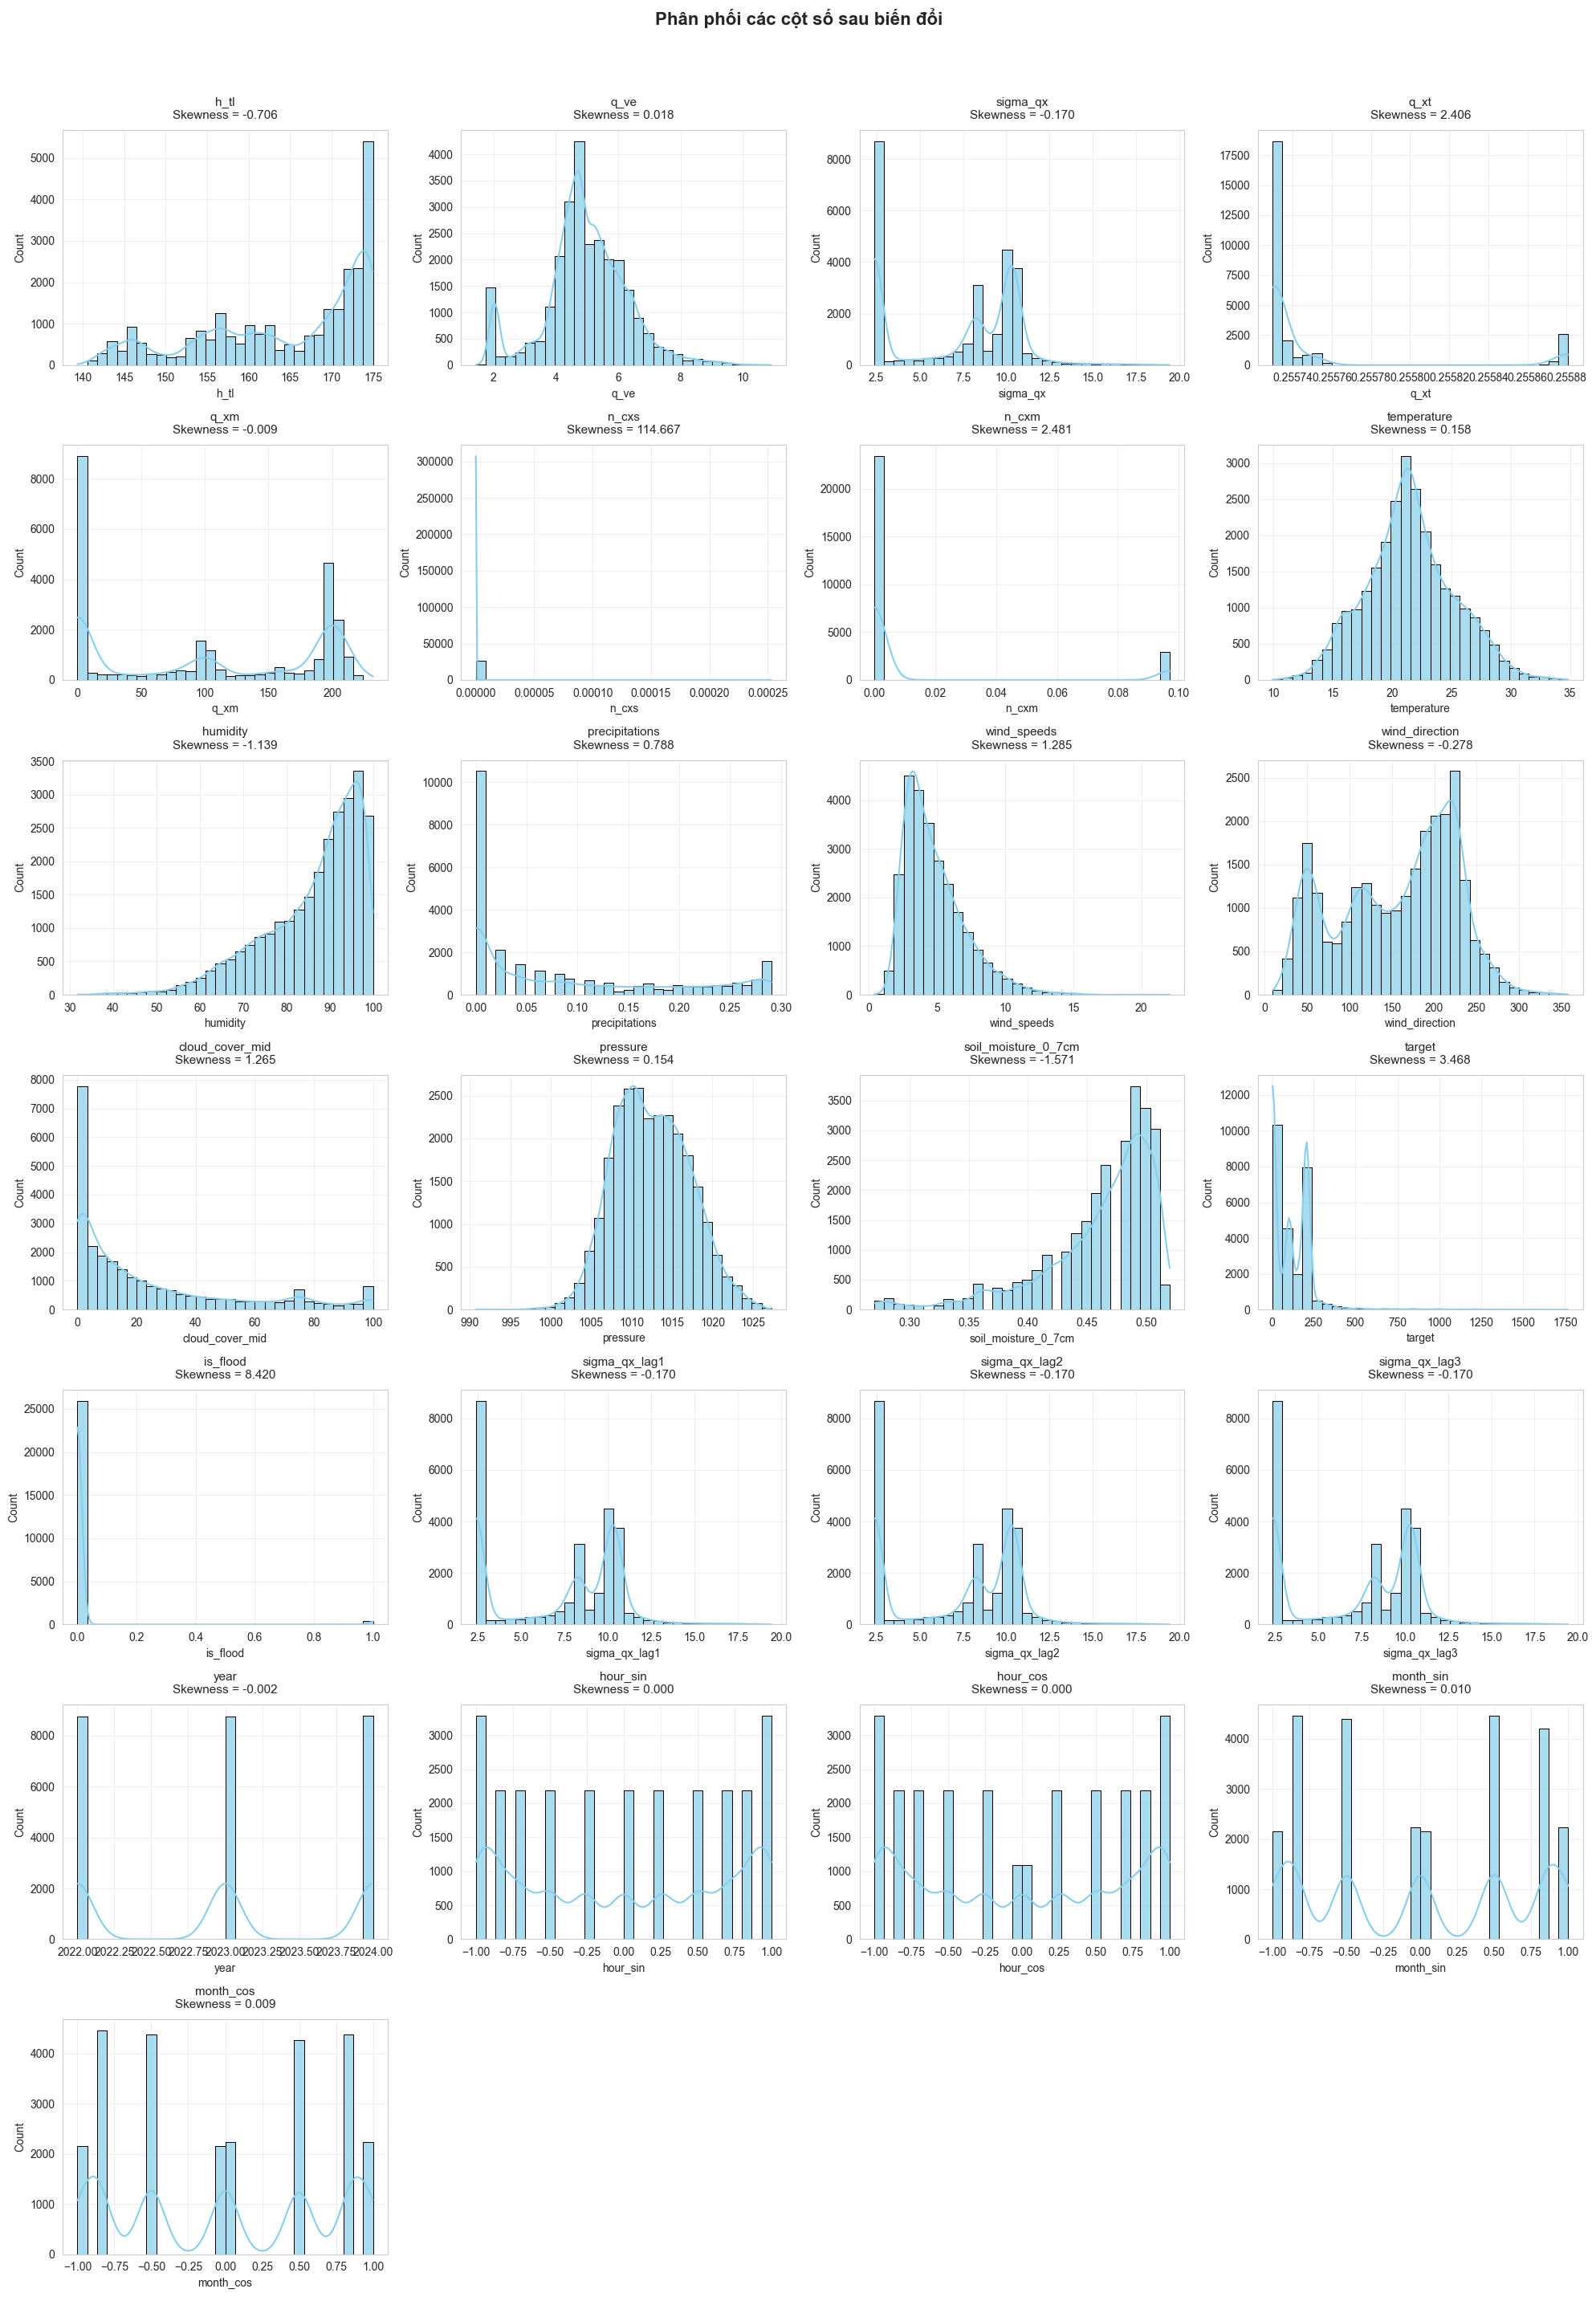

In [21]:
plot_distributions(train_processed_tree, title="Phân phối các cột số sau biến đổi")

In [22]:
# Apply pipeline lên test
test_processed_tree, _ = run_pipeline(
        df=test_df,
        cols_to_drop=COLS_TO_DROP,
        skew_cols=SKEW_COLS,
        scale_cols=None,
        use_standardize=False,
        fit_transformers=False,  # chỉ transform, không fit lại
        transform_info=info_tree,
        verbose=True,
    )


───────────────────────────────────────────────────────
  Pipeline — TEST  (input shape: (8759, 20))
───────────────────────────────────────────────────────

[1] Drop unnecessary columns
Đã drop 3 cột: ['h_dbt', 'h_c', 'ten_ho']

[2] Flood flag
Đã tạo cột 'is_flood' với flood_months=[10, 11, 12, 1] và q_ve_threshold=750

[3] Transform (skewness + scale)
   Áp dụng Yeo-Johnson (đã fit) trên 6 cột

[4] Lag features — cột 'sigma_qx', lags=[1, 2, 3]
Đã thêm 3 lag features cho cột 'sigma_qx': ['sigma_qx_lag1', 'sigma_qx_lag2', 'sigma_qx_lag3']

[5] Time features
Đã thêm time features với Cyclic Encoding (sin/cos)

  Pipeline hoàn tất — output shape: (8756, 25)


# Bước 4: Model Training

In [45]:
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import time
from joblib import dump, load

In [37]:
os.makedirs("Model/ST2", exist_ok=True)

## Lasso - Baseline

In [ ]:
def train_lasso_tuned_timeseries(train_df, target_col='target', n_splits=3):
    # Tách X và y
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]
    
    # Định nghĩa param grid cho alpha
    param_grid = {
        'alpha': [0.001, 0.01, 0.1, 0.5, 1, 5, 10]
    }
    
    # TimeSeries Cross Validation
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    best_model = None
    best_alpha = None
    best_mae = float('inf')
    time_scores = float('inf')
    
    print("=== Đang tuning Lasso cho Time Series ===")
    print(f"Sử dụng TimeSeriesSplit với {n_splits} splits\n")
    
    # Manual tuning vì TimeSeriesSplit + GridSearchCV đôi khi không mượt
    
    for alpha in param_grid['alpha']:
        mae_scores = []
        
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model = Lasso(alpha=alpha, max_iter=10000, random_state=42)
            model.fit(X_tr, y_tr)
            
            y_pred_val = model.predict(X_val)
            mae = mean_absolute_error(y_val, y_pred_val)
            mae_scores.append(mae)
        
        avg_mae = np.mean(mae_scores)
        
        print(f"Alpha = {alpha:8} | Avg MAE = {avg_mae:,.4f}")
        
        # Cập nhật best model
        if avg_mae < best_mae:
            best_mae = avg_mae
            best_alpha = alpha
            best_model = Lasso(alpha=alpha, max_iter=10000, random_state=42)
            start_time = time.time()
            best_model.fit(X_train, y_train)   # Train lại trên toàn bộ train set
            end_time = time.time()
            time_scores = end_time-start_time

    
    print("\n" + "="*50)
    print(f"Best Alpha     : {best_alpha}")
    print(f"Best MAE (CV)  : {best_mae:,.4f}")
    print(f"Best training time: {time_scores:.2f}")
    print("="*50)
    
    return best_model, best_alpha, best_mae


def print_feature_importance(model, train_df, target_col='target', top_n=20):
    X_columns = train_df.drop(columns=[target_col]).columns
    
    coef_df = pd.DataFrame({
        'Feature': X_columns,
        'Coefficient': model.coef_
    })
    
    # Chỉ giữ features có hệ số khác 0
    coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])
    coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)
    
    print(f"\n=== Top {top_n} Features quan trọng nhất (Lasso) ===")
    print(coef_df.head(top_n)[['Feature', 'Coefficient']].round(6).to_string(index=False))
    
    coef_df = coef_df[coef_df['Coefficient'] != 0].copy()
    print(f"\nTổng số features được giữ lại: {len(coef_df)} / {len(X_columns)}")
    
    return coef_df

In [33]:
lasso_best_model, lasso_best_alpha, _ = train_lasso_tuned_timeseries(train_processed)
lasso_coef = print_feature_importance(lasso_best_model, train_processed)

=== Đang tuning Lasso cho Time Series ===
Sử dụng TimeSeriesSplit với 3 splits

Alpha =    0.001 | Avg MAE = 42.4290
Alpha =     0.01 | Avg MAE = 42.4048
Alpha =      0.1 | Avg MAE = 42.0907
Alpha =      0.5 | Avg MAE = 41.2257
Alpha =        1 | Avg MAE = 40.8188
Alpha =        5 | Avg MAE = 41.7359
Alpha =       10 | Avg MAE = 44.0791

Best Alpha     : 1
Best MAE (CV)  : 40.8188
Best training time: 0.80

=== Top 20 Features quan trọng nhất (Lasso) ===
            Feature  Coefficient
           is_flood   230.409545
           sigma_qx    96.277098
              n_cxm    26.448952
               q_xm   -14.379255
           hour_sin    -4.751836
               q_ve     4.654661
     precipitations     4.386784
           pressure    -4.167949
               q_xt     3.782503
        wind_speeds     3.007494
               h_tl     1.742336
     wind_direction    -1.436642
          month_cos     0.559018
        temperature     0.088593
           humidity     0.000000
soil_moisture_

In [39]:
dump(lasso_best_model, "Model/ST2/Lasso_best_model.pkl")
size = os.path.getsize("Model/ST2/Lasso_best_model.pkl")
print(size / (1024 * 1024), "MB")

0.0012884140014648438 MB


## Random Forest

In [47]:
def train_rf_tuned_timeseries(train_df, target_col='target', n_splits=3):
    # Tách X và y
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]
    
    # Param grid cho Random Forest
    param_grid = {
        'n_estimators': [100, 500, 1000],
        'max_depth': [None, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    # TimeSeries Cross Validation
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    best_model = None
    best_params = None
    best_mae = float('inf')
    time_scores = float('inf')
    
    print("=== Đang tuning Random Forest cho Time Series ===")
    print(f"Sử dụng TimeSeriesSplit với {n_splits} splits\n")
    print(f"Tổng số combinations: {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf'])}\n")
    
    # Manual tuning loop
    for n_est in param_grid['n_estimators']:
        for depth in param_grid['max_depth']:
            for split in param_grid['min_samples_split']:
                for leaf in param_grid['min_samples_leaf']:
                    
                    params = {
                        'n_estimators': n_est,
                        'max_depth': depth,
                        'min_samples_split': split,
                        'min_samples_leaf': leaf,
                        'random_state': 42,
                        'n_jobs': -1
                    }
                    
                    mae_scores = []
                    
                    for train_idx, val_idx in tscv.split(X_train):
                        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
                        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                        
                        model = RandomForestRegressor(**params)
                        model.fit(X_tr, y_tr)

                        # Dự đoán và tính MAE
                        y_pred_val = model.predict(X_val)
                        mae = mean_absolute_error(y_val, y_pred_val)
                        mae_scores.append(mae)
                    
                    avg_mae = np.mean(mae_scores)
                    
                    print(f"n_est={n_est:3} | max_depth={str(depth):4} | min_split={split} | "
                          f"min_leaf={leaf} | MAE={avg_mae:,.4f}")
                    
                    # Cập nhật best model
                    if avg_mae < best_mae:
                        best_mae = avg_mae
                        best_params = params
                        best_model = RandomForestRegressor(**params)
                        start_time = time.time()
                        best_model.fit(X_train, y_train)   # Train lại trên toàn bộ train set
                        end_time = time.time()
                        time_scores = end_time-start_time
    
    print("\n" + "="*80)
    print(f"Best Params   : {best_params}")
    print(f"Best MAE (CV) : {best_mae:,.4f}")
    print(f"Best training time: {time_scores:.2f}")
    print("="*80)
    
    return best_model, best_params, best_mae


# ====================== FEATURE IMPORTANCE CHO RANDOM FOREST ======================
def print_feature_importance_tree(model, train_df, model_name = "Random Forest", target_col='target', top_n=24):
    X_columns = train_df.drop(columns=[target_col]).columns
    
    importance_df = pd.DataFrame({
        'Feature': X_columns,
        'Importance': model.feature_importances_
    })
    
    importance_df = importance_df.sort_values(by='Importance', ascending=False)
    
    print(f"\n=== Top {top_n} Features quan trọng nhất ({model_name}) ===")
    print(importance_df.head(top_n).round(6).to_string(index=False))
    
    print(f"\nTổng số features: {len(importance_df)}")
    
    return importance_df

In [ ]:
rf_best_model, rf_best_params, rf_best_mae = train_rf_tuned_timeseries(train_processed_tree)
rf_importance = print_feature_importance_tree(rf_best_model, train_processed_tree)

=== Đang tuning Random Forest cho Time Series ===
Sử dụng TimeSeriesSplit với 3 splits

Tổng số combinations: 108

n_est=100 | max_depth=None | min_split=2 | min_leaf=1 | MAE=27.8114
n_est=100 | max_depth=None | min_split=2 | min_leaf=2 | MAE=26.8749
n_est=100 | max_depth=None | min_split=2 | min_leaf=4 | MAE=25.8673
n_est=100 | max_depth=None | min_split=5 | min_leaf=1 | MAE=27.7803
n_est=100 | max_depth=None | min_split=5 | min_leaf=2 | MAE=26.8766
n_est=100 | max_depth=None | min_split=5 | min_leaf=4 | MAE=25.8673
n_est=100 | max_depth=None | min_split=10 | min_leaf=1 | MAE=27.5554
n_est=100 | max_depth=None | min_split=10 | min_leaf=2 | MAE=26.6993
n_est=100 | max_depth=None | min_split=10 | min_leaf=4 | MAE=25.8069
n_est=100 | max_depth=10   | min_split=2 | min_leaf=1 | MAE=25.5370
n_est=100 | max_depth=10   | min_split=2 | min_leaf=2 | MAE=25.1256
n_est=100 | max_depth=10   | min_split=2 | min_leaf=4 | MAE=24.8796
n_est=100 | max_depth=10   | min_split=5 | min_leaf=1 | MAE=25.484

In [44]:
dump(rf_best_model, "Model/ST2/RF_best_model.pkl")
size = os.path.getsize("Model/ST2/RF_best_model.pkl")
print(size / (1024 * 1024), "MB")

27.13240146636963 MB


## XGBoost

In [50]:
def train_xgb_tuned_timeseries(train_df, target_col='target', n_splits=3):
    # Tách X và y
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]
    
    # Param grid cho XGBoost (cân bằng giữa hiệu suất và tốc độ)
    param_grid = {
        'n_estimators': [100, 500, 1000],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'min_child_weight': [1, 3, 5]
    }
    
    # TimeSeries Cross Validation
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    best_model = None
    best_params = None
    best_mae = float('inf')
    time_scores = float('inf')
    
    print("=== Đang tuning XGBoost cho Time Series ===")
    print(f"Sử dụng TimeSeriesSplit với {n_splits} splits")
    print("Lưu ý: Tuning XGBoost có thể mất khá nhiều thời gian\n")
    
    # Manual tuning loop
    for n_est in param_grid['n_estimators']:
        for depth in param_grid['max_depth']:
            for lr in param_grid['learning_rate']:
                for subsample in param_grid['subsample']:
                    for colsample in param_grid['colsample_bytree']:
                        for min_child in param_grid['min_child_weight']:
                            
                            params = {
                                'n_estimators': n_est,
                                'max_depth': depth,
                                'learning_rate': lr,
                                'subsample': subsample,
                                'colsample_bytree': colsample,
                                'min_child_weight': min_child,
                                'random_state': 42,
                                'n_jobs': -1,
                                'verbosity': 0          # Tắt log XGBoost
                            }
                            
                            mae_scores = []
                            
                            for train_idx, val_idx in tscv.split(X_train):
                                X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
                                y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                                
                                model = XGBRegressor(**params)
                                model.fit(X_tr, y_tr)

                                # Dự đoán và tính MAE
                                y_pred_val = model.predict(X_val)
                                mae = mean_absolute_error(y_val, y_pred_val)
                                mae_scores.append(mae)
                            
                            avg_mae = np.mean(mae_scores)
                            
                            print(f"n_est={n_est:3} | depth={depth:2} | lr={lr:.3f} | "
                                  f"sub={subsample:.1f} | col={colsample:.1f} | "
                                  f"child={min_child} | MAE={avg_mae:,.4f}")
                            
                            # Cập nhật best model
                            if avg_mae < best_mae:
                                best_mae = avg_mae
                                best_params = params
                                best_model = XGBRegressor(**params)
                                start_time = time.time()
                                best_model.fit(X_train, y_train)   # Train lại trên toàn bộ train set
                                end_time = time.time()
                                time_scores = end_time-start_time
    
    print("\n" + "="*90)
    print(f"Best Params   : {best_params}")
    print(f"Best MAE (CV) : {best_mae:,.4f}")
    print(f"Best training time: {time_scores:.2f}")
    print("="*90)
    
    return best_model, best_params, best_mae

In [51]:
xgb_best_model, xgb_best_params, xgb_best_mae = train_xgb_tuned_timeseries(train_processed_tree)
xgb_importance = print_feature_importance_tree(rf_best_model, train_processed_tree, "XGBoost")

=== Đang tuning XGBoost cho Time Series ===
Sử dụng TimeSeriesSplit với 3 splits
Lưu ý: Tuning XGBoost có thể mất khá nhiều thời gian

n_est=100 | depth= 3 | lr=0.010 | sub=0.8 | col=0.8 | child=1 | MAE=51.8289
n_est=100 | depth= 3 | lr=0.010 | sub=0.8 | col=0.8 | child=3 | MAE=51.8289
n_est=100 | depth= 3 | lr=0.010 | sub=0.8 | col=0.8 | child=5 | MAE=51.8293
n_est=100 | depth= 3 | lr=0.010 | sub=0.8 | col=1.0 | child=1 | MAE=51.6999
n_est=100 | depth= 3 | lr=0.010 | sub=0.8 | col=1.0 | child=3 | MAE=51.6999
n_est=100 | depth= 3 | lr=0.010 | sub=0.8 | col=1.0 | child=5 | MAE=51.7007
n_est=100 | depth= 3 | lr=0.010 | sub=1.0 | col=0.8 | child=1 | MAE=51.8361
n_est=100 | depth= 3 | lr=0.010 | sub=1.0 | col=0.8 | child=3 | MAE=51.8361
n_est=100 | depth= 3 | lr=0.010 | sub=1.0 | col=0.8 | child=5 | MAE=51.8361
n_est=100 | depth= 3 | lr=0.010 | sub=1.0 | col=1.0 | child=1 | MAE=51.6824
n_est=100 | depth= 3 | lr=0.010 | sub=1.0 | col=1.0 | child=3 | MAE=51.6824
n_est=100 | depth= 3 | lr=0.0

In [52]:
dump(xgb_best_model, "Model/ST2/XGB_best_model.pkl")
size = os.path.getsize("Model/ST2/XGB_best_model.pkl")
print(size / (1024 * 1024), "MB")

0.2499065399169922 MB


# Bước 5: Model Evaluation

In [53]:
lasso_best_model = load("Model/ST2/Lasso_best_model.pkl")
rf_best_model = load("Model/ST2/RF_best_model.pkl")
xgb_best_model = load("Model/ST2/XGB_best_model.pkl")

In [61]:
def evaluate_model(model, test_df, model_name = "LASSO", target_col='target'):
    # Tách features và target
    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col]
    
    # Dự đoán
    y_pred = model.predict(X_test)
    
    # Tính các metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # In kết quả
    print(f"====== MODEL EVALUATION ON TEST SET FOR {model_name} ======")
    print(f"MAE  : {mae:,.4f}")
    print(f"RMSE : {rmse:,.4f}")
    print(f"R²   : {r2:,.4f}")
    print("=" * 50)
    
    return y_pred

In [62]:
lasso_pred = evaluate_model(lasso_best_model, test_processed)
rf_pred = evaluate_model(rf_best_model, test_processed_tree, "RANDOM FOREST")
xgb_pred = evaluate_model(xgb_best_model, test_processed_tree, "XGBOOST")

====== MODEL EVALUATION ON TEST SET FOR LASSO ======
MAE  : 1,691.1440
RMSE : 5,816.6875
R²   : -326.1461
====== MODEL EVALUATION ON TEST SET FOR RANDOM FOREST ======
MAE  : 34.8119
RMSE : 139.1172
R²   : 0.8129
====== MODEL EVALUATION ON TEST SET FOR XGBOOST ======
MAE  : 41.4293
RMSE : 162.6277
R²   : 0.7443


In [ ]:
def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted (Time Series)", 
                             figsize=(12, 6), date_index=None):
    # Chuyển về numpy array để dễ xử lý
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # Tạo figure
    plt.figure(figsize=figsize)
    
    # Vẽ hai đường
    if date_index is not None:
        plt.plot(date_index, y_true, label='Actual (y_true)', color='blue', linewidth=2)
        plt.plot(date_index, y_pred, label='Predicted (y_pred)', color='red', linestyle='--', linewidth=2)
        plt.xlabel('Time')
    else:
        # Nếu không có date_index, dùng index mặc định
        plt.plot(y_true, label='Actual (y_true)', color='blue', linewidth=2)
        plt.plot(y_pred, label='Predicted (y_pred)', color='red', linestyle='--', linewidth=2)
        plt.xlabel('Time Index')
    
    # Thiết lập biểu đồ
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Value')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Thêm khoảng cách giữa các nhãn trục x nếu cần
    plt.xticks(rotation=45)
    
    # Hiển thị
    plt.tight_layout()
    plt.show()

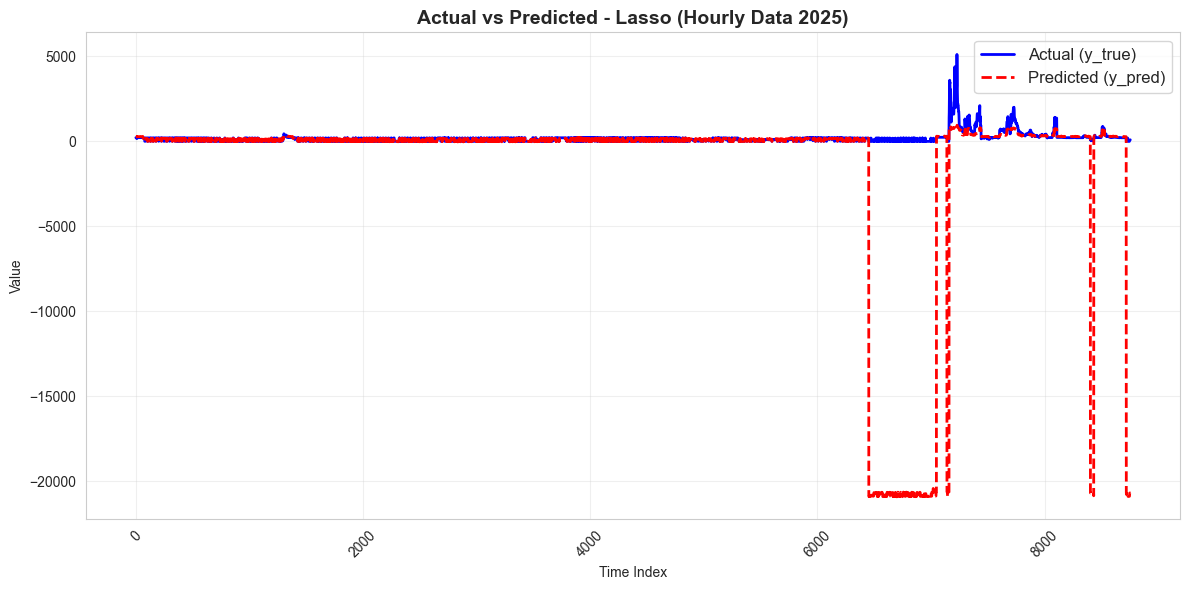

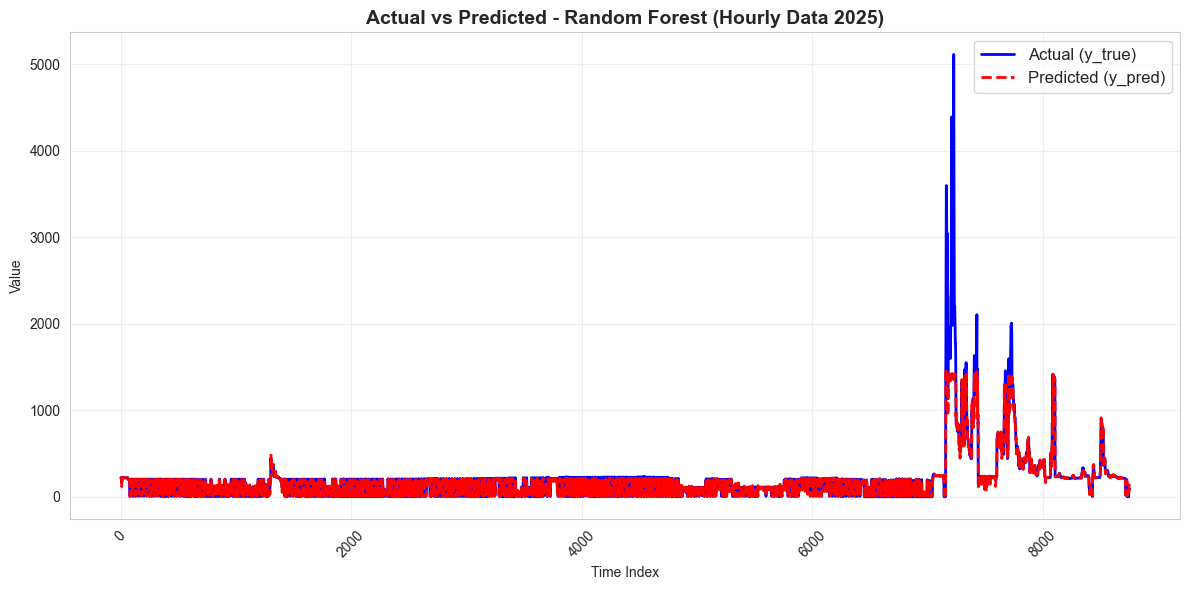

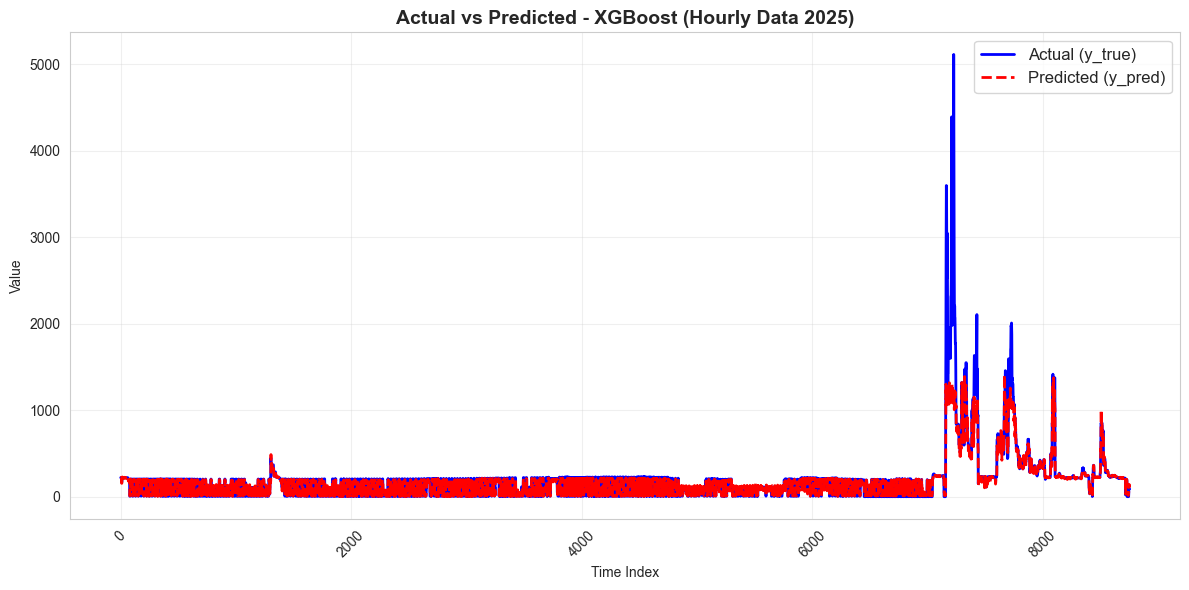

In [68]:
# Vẽ biểu đồ
y_true=test_processed["target"]

plot_actual_vs_predicted(
    y_true=y_true,
    y_pred=lasso_pred,
    title="Actual vs Predicted - Lasso (Hourly Data 2025)"
)

plot_actual_vs_predicted(
    y_true=y_true,
    y_pred=rf_pred,
    title="Actual vs Predicted - Random Forest (Hourly Data 2025)"
)

plot_actual_vs_predicted(
    y_true=y_true,
    y_pred=xgb_pred,
    title="Actual vs Predicted - XGBoost (Hourly Data 2025)"
)

# Bước 6: Phân tích và Sửa lỗi

Nhìn chung, với các mô hình dạng cây quyết định, khả năng dự đoán khá tốt theo xu hướng của dữ liệu. Điểm tệ duy nhất được thấy ở chỗ khả năng dự đoán và mùa mưa bão. Mô hình vẫn biết và dự đoán với giá trị lớn hơn, tuy nhiên với một số giá trị cực lớn thì vẫn không thể dự đoán ra được.  
Để giải thích cho vấn đề này, khi quan sát phân phối dữ liệu trong tập train, giá trị max của target mà mô hình có thể thấy chỉ nằm ở khoảng 1200 - 1500. Tuy nhiên trong tập test, giá trị này lại lên tới 5000, hoàn toàn tách biệt so với tập train. Vấn đề này gọi là data shift khi distribution của train và test là khác nhau.  
Liên hệ với thực tế, vào cuối năm 2025, các đợt mưa bão vô cùng lớn đổ bộ vào miền Trung nước ta, đặc biệt là khu vực lưu vực sông Tranh và sông Thu Bồn. Các nhà máy điện lực liên tục xả nước để tránh nguy cơ vỡ đập, dẫn tới lượng nước xả ra lớn hơn rất nhiều so với các năm trước đó. Có thể nói nguyên nhân dẫn tới sai lệch lớn trong kết quả dự đoán có mang yếu tố quyết định của con người.  
Do vậy, thay vì cố gắng khắc phục lỗi dựa trên những gì bộ dữ liệu có được, ta sẽ tiến hành việc loại bỏ các thuộc tính mà mỗi mô hình cho rằng không quan trọng để quan sát lại hiệu quả. Nói tóm lại, có thể đánh giá các mô hình random forest hay xgboost đều đã hoạt động rất tốt.

In [69]:
lasso_train_df = train_processed.drop(columns = ["humidity", "soil_moisture_0_7cm",
                                                 "sigma_qx_lag1", "sigma_qx_lag2",
                                                 "sigma_qx_lag3", "year"])
lasso_test_df = test_processed.drop(columns = ["humidity", "soil_moisture_0_7cm",
                                                 "sigma_qx_lag1", "sigma_qx_lag2",
                                                 "sigma_qx_lag3", "year"])

tree_train_df = train_processed_tree.drop(columns=["n_cxs"])
tree_test_df = test_processed_tree.drop(columns=["n_cxs"])

In [75]:
lasso_update = Lasso(alpha = 1, max_iter=10000, random_state=42)
X_train = lasso_train_df.drop(columns=["target"])
y_train = lasso_train_df["target"]
lasso_update.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [76]:
rf_update = RandomForestRegressor(n_estimators = 500, max_depth = 10, min_samples_split = 10, 
                                  min_samples_leaf = 4, random_state = 42, n_jobs = -1)
X_train = tree_train_df.drop(columns=["target"])
y_train = tree_train_df["target"]
rf_update.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [77]:
xgb_update = XGBRegressor(n_estimators = 100, max_depth = 5, learning_rate = 0.05, subsample = 0.8, 
                          colsample_bytree = 0.8, min_child_weight = 5, random_state = 42, n_jobs = -1, verbosity = 0)
X_train = tree_train_df.drop(columns=["target"])
y_train = tree_train_df["target"]
xgb_update.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = loa

In [78]:
lasso_pred = evaluate_model(lasso_update, lasso_test_df)
rf_pred = evaluate_model(rf_update, tree_test_df, "RANDOM FOREST")
xgb_pred = evaluate_model(xgb_update, tree_test_df, "XGBOOST")

====== MODEL EVALUATION ON TEST SET FOR LASSO ======
MAE  : 1,690.7448
RMSE : 5,815.2570
R²   : -325.9852
====== MODEL EVALUATION ON TEST SET FOR RANDOM FOREST ======
MAE  : 34.8016
RMSE : 139.1054
R²   : 0.8129
====== MODEL EVALUATION ON TEST SET FOR XGBOOST ======
MAE  : 40.8146
RMSE : 161.7794
R²   : 0.7469


Độ lỗi không cải thiện, thậm chí còn tăng lên -> bác bỏ.
Chấp nhận kết quả hiện tại